# Text Mining Project — Experiments

Predicting **market sentiment** from financial tweets: **Bearish (0)**, **Bullish (1)**, **Neutral (2)**.

This notebook follows this pipeline: data exploration → split → preprocessing → feature engineering (BoW, word2vec, Transformer encoder) → classification (traditional ML + Transformer encoders) → evaluation, plus the extra work (decoder-for-classification, agentic workflow) and a theory-grounded synthesis.

**Environment:** CPU-only, free/local tools only. All expensive steps are cached to `cache/` and reload on re-run, so re-executing the notebook never recomputes them.


## Section 0 — Setup & Configuration
Imports, reproducibility seeds, global config, the caching helper and the shared evaluation utilities used by every model so results are directly comparable.


In [1]:
import os, re, json, string, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)


In [2]:
# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
try:
    import torch
    torch.manual_seed(RANDOM_STATE)
except ImportError:
    pass


In [3]:
# Global config
DATA_DIR  = "./data/"          # folder with train.csv / test.csv 
CACHE_DIR = "cache"
os.makedirs(CACHE_DIR, exist_ok=True)

GROUP_ID = "12"

LABELS       = [0, 1, 2]
LABEL_NAMES  = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
TARGET_NAMES = [LABEL_NAMES[i] for i in LABELS] 


In [4]:
# Caching helper: build once, reload forever
import joblib

def cache_path(name): return os.path.join(CACHE_DIR, name)

def load_or_build(name, build_fn):
    """Idempotent cache.
    If the artifact exists it is LOADED (never recomputed). Otherwise built, saved, returned.
    Keras models are handled separately"""
    path = cache_path(name)
    ext  = os.path.splitext(name)[1].lower()
    if os.path.exists(path):
        print(f"[cache] load  {name}")
        if ext == ".npy":              return np.load(path, allow_pickle=True)
        if ext in (".joblib", ".pkl"): return joblib.load(path)
        if ext == ".json":
            with open(path) as f:      return json.load(f)
    print(f"[cache] build {name} ...")
    obj = build_fn()
    if ext == ".npy":              np.save(path, obj)
    elif ext in (".joblib", ".pkl"): joblib.dump(obj, path)
    elif ext == ".json":
        with open(path, "w") as f: json.dump(obj, f, indent=2)
    return obj


In [ ]:
# Shared evaluation utilities
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)

RESULTS = []

def evaluate(y_true, y_pred, feature_name, model_name, log=True, show=True):
    """Print per-class precision/recall/F1 + macro-F1 and log macro-F1 for comparison.
    Macro-F1 is the headline metric because the classes are imbalanced (verified in Sec.1)."""
    rep = classification_report(y_true, y_pred, labels=LABELS,
                                target_names=TARGET_NAMES, output_dict=True, zero_division=0)
    macro_f1 = rep["macro avg"]["f1-score"]
    acc      = rep["accuracy"]
    if show:
        print(classification_report(y_true, y_pred, labels=LABELS,
              target_names=TARGET_NAMES, zero_division=0))
        print(f"Accuracy: {acc:.4f}  |  Macro-F1: {macro_f1:.4f}")
    if log:
        RESULTS.append({
            "feature": feature_name, "model": model_name,
            "macro_f1": macro_f1, "accuracy": acc,
            "f1_bearish": rep["Bearish"]["f1-score"],
            "f1_bullish": rep["Bullish"]["f1-score"],
            "f1_neutral": rep["Neutral"]["f1-score"],
        })
    return macro_f1

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title); plt.tight_layout(); plt.show()


In [6]:
# NLTK resources - stopwords, stemmer, lemmatizer
import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer

STOP    = set(stopwords.words("english"))
LEMMA   = WordNetLemmatizer()
STEMMER = SnowballStemmer("english")


## Section 1 — Data Loading & Exploration

Goal is to understand the corpus before modelling and let what we observe *drive* the later choices (metric, splitting, preprocessing).

### 1.1 Load and Sanity Check

Why: before anything else we confirm the data is what the handout describes and decide two things that affect our project: **how the test `id` is represented** and **whether duplicates/nulls exist** (duplicates can leak across the train/val split and inflate scores; empty tweets can't be classified).


In [7]:
def read_csv_safe(path):
    for enc in ["utf-8", "latin-1"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="latin-1", engine="python")

train_df = read_csv_safe(os.path.join(DATA_DIR, "train.csv"))
test_df  = read_csv_safe(os.path.join(DATA_DIR, "test.csv"))

print("train shape:", train_df.shape, "| test shape:", test_df.shape)
print("train columns:", list(train_df.columns))
print("test  columns:", list(test_df.columns))
train_df.head()


train shape: (9543, 2) | test shape: (2388, 2)
train columns: ['text', 'label']
test  columns: ['id', 'text']


,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0


In [8]:
# Normalise expected column names if needed (handout uses 'text' and 'label').
assert "text" in train_df.columns and "label" in train_df.columns, \
    f"Expected 'text' & 'label' in train; got {list(train_df.columns)}"
assert "text" in test_df.columns, f"Expected 'text' in test; got {list(test_df.columns)}"

print("Labels present in train:", sorted(train_df["label"].dropna().unique()))
print("Null text (train):", int(train_df["text"].isna().sum()))
print("Empty text (train):", int((train_df["text"].astype(str).str.strip() == "").sum()))
print("Exact duplicate tweets (train):", int(train_df["text"].duplicated().sum()))


Labels present in train: [0, 1, 2]
Null text (train): 0
Empty text (train): 0
Exact duplicate tweets (train): 0


In [9]:
# Resolve the TEST id mechanism (handout: pred file = 'id of the test set' + predicted label).
ID_COL = None
for cand in ["id", "Id", "ID", "index", "Unnamed: 0"]:
    if cand in test_df.columns:
        ID_COL = cand
        break
print(f"Test id column: {ID_COL!r}" if ID_COL else
      "No explicit id column -> the row index (0..N-1) will be used as id in pred_xx.csv")


Test id column: 'id'


In [10]:
# Clean the TRAIN set of leakage/no-signal rows (test set is left untouched).
before = len(train_df)
train_df = train_df.dropna(subset=["text"])
train_df = train_df[train_df["text"].astype(str).str.strip() != ""]
train_df = train_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Dropped {before - len(train_df)} null/empty/duplicate rows -> train now {len(train_df)}")


Dropped 0 null/empty/duplicate rows -> train now 9543


### Analysis 1.1 — data integrity
The corpus matches the handout on size: **9,543 training rows** with `text` + `label`, labels exactly `{0,1,2}`. **No nulls, no empty strings and no duplicate tweets**, so the dedup/cleaning step removed 0 rows and there is no train/validation leakage risk from repeats.

One discrepancy: `test.csv` contains **2,388 rows** (columns `id`, `text`), not the 299 the handout text mentions. The test **id is an explicit `id` column**, which we use directly in `pred_xx.csv`.

*Why this matters:* clean, de-duplicated data with a known id field means our validation scores are trustworthy.

### 1.2 Label distribution and Majority baselines

Why: the class balance decides our **evaluation metric** and **modelling safeguards**. We compute two baselines: majority-class **accuracy** and majority-class **macro-F1**, since on an imbalanced 3-class problem they tell very different stories: always predicting the biggest class can score high accuracy yet near-zero F1 on the minority classes. Whatever the data shows here is what justifies the metric and the class-weighting used later.


Class distribution (train):
  0 Bearish :  1442  ( 15.1%)
  1 Bullish :  1923  ( 20.2%)
  2 Neutral :  6178  ( 64.7%)

Majority class: 2 (Neutral)
Majority-class ACCURACY : 0.6474
Majority-class MACRO-F1 : 0.2620


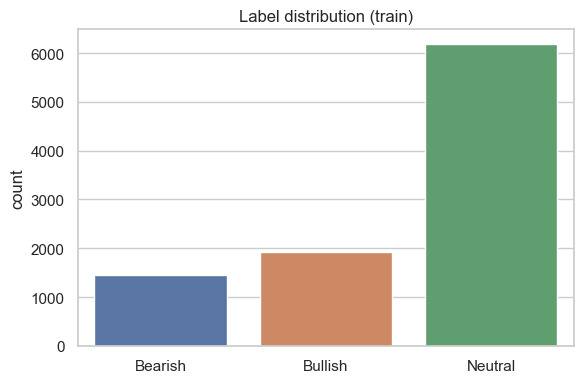

In [11]:
counts = train_df["label"].value_counts().sort_index()
total  = len(train_df)
print("Class distribution (train):")
for lbl in LABELS:
    c = int(counts.get(lbl, 0))
    print(f"  {lbl} {LABEL_NAMES[lbl]:<8}: {c:>5}  ({c/total*100:5.1f}%)")

maj          = int(counts.idxmax())
maj_acc      = counts.max() / total
y_all        = train_df["label"].values
maj_macro_f1 = f1_score(y_all, np.full_like(y_all, maj), average="macro")
print(f"\nMajority class: {maj} ({LABEL_NAMES[maj]})")
print(f"Majority-class ACCURACY : {maj_acc:.4f}")
print(f"Majority-class MACRO-F1 : {maj_macro_f1:.4f}")

plt.figure(figsize=(6, 4))
order = [LABEL_NAMES[l] for l in counts.index]
sns.barplot(x=order, y=counts.values, hue=order, legend=False, palette="deep")
plt.title("Label distribution (train)"); plt.ylabel("count"); plt.tight_layout(); plt.show()


### Analysis 1.2 — Class balance
The data is **strongly imbalanced**: **Neutral 64.7%** (6,178), **Bullish 20.2%** (1,923), **Bearish 15.1%** (1,442). The decisive number is the gap between the two majority baselines: always-predict-Neutral scores **0.647 accuracy** but only **0.262 macro-F1** (F1 = 0 on both Bearish and Bullish).

**Decisions this forces:**
- **Headline metric = macro-F1**, never accuracy since a model can hit 65% accuracy and be useless on the two classes investors actually care about.
- **Stratified** train/val split and **stratified** 5-fold CV, so the minority classes stay represented.
- **`class_weight='balanced'`** on Logistic Regression and a class-weight dict on the BiLSTM.
- For every model we watch **Bearish/Bullish recall** and the confusion matrix.

*Why this matters:* the 0.385 gap between majority accuracy (0.647) and majority macro-F1 (0.262) is the single fact that justifies our entire evaluation and class-weighting strategy.

### 1.3 Per-class vocabularyand Word clouds

Why: we look at the most frequent words per class to judge whether the three classes are **lexically separable** (i.e. whether simple word-based features could already discriminate them). (We use a throwaway lowercase + stopword tokenisation here purely for visualisation; the real preprocessing decisions are made in Section 3.) What we read off here sets expectations to *test* later.


[Bearish] top words: ['stock', 'china', 'misses', 'coronavirus', 'oil', 'market', 'economy', 'price', 'stocks', 'shares', 'cut', 'says', 'revenue', 'sales', 'trade']


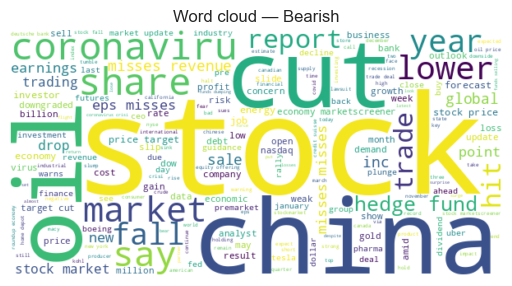

[Bullish] top words: ['stock', 'beats', 'price', 'target', 'stocks', 'shares', 'market', 'revenue', 'new', 'eps', 'trade', 'china', 'raised', 'higher', 'economy']


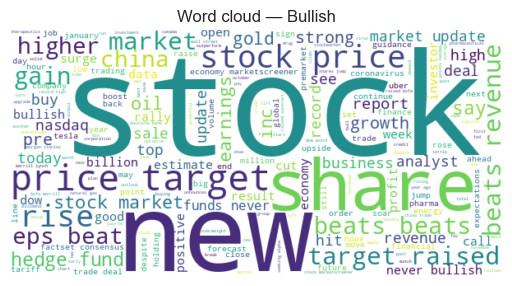

[Neutral] top words: ['stock', 'marketscreener', 'results', 'new', 'earnings', 'dividend', 'says', 'inc', 'reports', 'call', 'economy', 'market', 'declares', 'year', 'stocks']


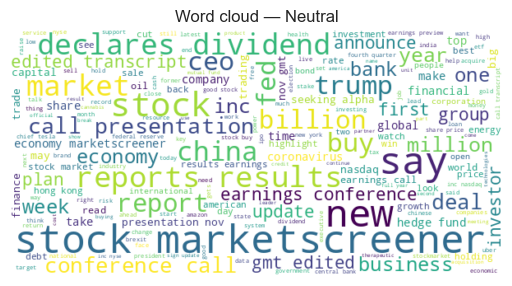

In [12]:
from collections import Counter
from wordcloud import WordCloud

def quick_tokens(s):
    s = re.sub(r"http\S+", "", str(s).lower())
    s = re.sub(r"[^a-z\s]", " ", s)
    return [w for w in s.split() if w not in STOP and len(w) > 2]

for lbl in LABELS:
    texts = train_df.loc[train_df["label"] == lbl, "text"]
    toks  = [t for s in texts for t in quick_tokens(s)]
    top   = Counter(toks).most_common(15)
    print(f"[{LABEL_NAMES[lbl]}] top words: {[w for w, _ in top]}")
    if toks:
        wc = WordCloud(width=600, height=300, background_color="white").generate(" ".join(toks))
        plt.figure(figsize=(7, 3.2)); plt.imshow(wc, interpolation="bilinear")
        plt.axis("off"); plt.title(f"Word cloud — {LABEL_NAMES[lbl]}"); plt.show()


### Analysis 1.3 — Lexical separability
The classes use **clearly distinct vocabulary**, which bodes well for word-based features:
- **Bearish:** *misses, cut, slip, slide, fall, downgraded, loss, weak, warns* — plus crisis terms (*coronavirus, oil*).
- **Bullish:** *beats, target, raised, higher, upgraded, strong, jump, rise, eps* — earnings-beat language.
- **Neutral:** *marketscreener, results, reports, declares, dividend, call, q3, inc* — factual/reporting language and data-vendor boilerplate.

There is a visible **generalisation risk**: company/data-source names (e.g. *marketscreener*, tickers) appear among the top tokens, so a model could latch onto *names* rather than *sentiment*. This is exactly why we normalise cashtags to a generic `ticker` token in preprocessing.

*Why this matters:* because the lexicon is so separable, we should expect a strong **TF-IDF + Logistic Regression** baseline and indeed it reaches 0.709, beating generic DistilBERT (0.697)(we would see later in the notebook).

### 1.4 Financial-domain signals

Why: the lab pipelines were built for product/COVID text and simply delete every non-letter character. Financial tweets carry signal in exactly those characters: cashtags (`$AAPL`), percentages (`5%`), dollar amounts, hashtags, @mentions, URLs. We measure how often each appears **per class**. If a signal differs across classes, deleting it would destroy information(deeper in Section 3).

Fraction of tweets containing each signal, by class (%):
         cashtag  percent  money  hashtag  mention   url  number  allcaps
Bearish     13.8     16.3   10.1      6.8      2.1  44.3    37.9     40.8
Bullish     25.1     21.2   16.5      6.2      1.6  39.1    47.7     48.5
Neutral     12.2      3.1    9.4     11.0      3.8  49.8    29.8     41.5


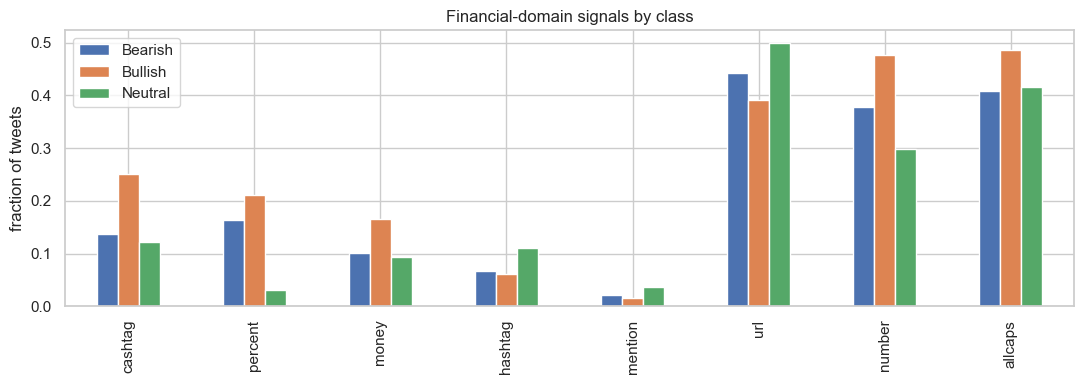

In [13]:
patterns = {
    "cashtag": r"\$[A-Za-z]{1,6}\b",
    "percent": r"\d+(?:\.\d+)?\s?%",
    "money":   r"\$\d+(?:[.,]\d+)?[kKmMbB]?\b",
    "hashtag": r"#\w+",
    "mention": r"@\w+",
    "url":     r"http\S+|www\.\S+",
    "number":  r"\b\d+(?:[.,]\d+)?\b",
    "allcaps": r"\b[A-Z]{2,}\b",
}
rows = []
for lbl in LABELS:
    texts = train_df.loc[train_df["label"] == lbl, "text"].astype(str)
    rows.append({name: texts.str.contains(pat, regex=True).mean()
                 for name, pat in patterns.items()})
sig = pd.DataFrame(rows, index=[LABEL_NAMES[l] for l in LABELS])
print("Fraction of tweets containing each signal, by class (%):")
print((sig * 100).round(1))

sig.T.plot(kind="bar", figsize=(11, 4))
plt.ylabel("fraction of tweets"); plt.title("Financial-domain signals by class")
plt.tight_layout(); plt.show()


### Analysis 1.4 — Domain signals
Finance-specific tokens **do carry class signal**, confirming they should not be blindly deleted:
- **Percentages** are the sharpest discriminator: present in **21.2%** of Bullish and **16.3%** of Bearish tweets but only **3.1%** of Neutral — directional moves (`+5%`, `−8%`) signal opinion.
- **Cashtags** lean Bullish (**25.1%** vs 13.8% Bearish, 12.2% Neutral); **numbers** likewise (Bullish **47.7%** vs Neutral 29.8%).
- Neutral tweets are the most "news-like": highest **URL** (49.8%), **hashtag** (11.0%) and **@mention** (3.8%) rates.

**Implication for Section 3:** the lab default cleaner deletes every digit/%/`$`, which would erase the percent signal entirely. So we test a **conservative variant** that *normalises* these to tokens (`ticker`, `pct`, `num`) and **keeps negation words**, against the **aggressive** lab-style variant.

*Why this matters:* the 21.2% vs 3.1% percent-rate gap is concrete evidence that "delete all non-letters" throws away discriminative information — the motivation for the whole preprocessing experiment.

### Conclusion of Section 1 — what the EDA tells us to do
1. **Imbalance (65/20/15)** ⇒ macro-F1 headline, stratified split + CV, class weighting, watch minority recall. (Baseline to beat: macro-F1 **0.262**.)
2. **Strong lexical separability** ⇒ expect a competitive TF-IDF baseline; contextual models should help but maybe not dramatically (tweets are short).
3. **Domain tokens carry signal** (esp. `%`) ⇒ test conservative (normalise `ticker`/`pct`/`num`, keep negation) vs aggressive cleaning; keep the winner.
4. **Name/ticker leakage risk** ⇒ normalise cashtags to a generic token so the model learns sentiment, not specific tickers (helps blind-test generalisation).

## Section 2 — Train / Validation Split

Why: we need an honest yardstick for model selection. We hold out a **stratified** 20% validation set (stratified so every class (including the minority ones) stays represented). We split **before** any cleaning or vectorising so that no information from validation leaks into training-time decisions (fit vectorizers on train only). Stratified K-Fold is reserved for hyperparameter tuning of finalists in Section 5; for the broad sweep we use this single fixed split so every model is compared on identical data.


In [14]:
from sklearn.model_selection import train_test_split

X = train_df["text"].reset_index(drop=True)
y = train_df["label"].reset_index(drop=True)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"train: {len(X_train_raw)}  |  val: {len(X_val_raw)}")
for name, yy in [("train", y_train), ("val", y_val)]:
    d = yy.value_counts(normalize=True).sort_index()
    print(name, {LABEL_NAMES[k]: round(v * 100, 1) for k, v in d.items()})


train: 7634  |  val: 1909
train {'Bearish': 15.1, 'Bullish': 20.1, 'Neutral': 64.7}
val {'Bearish': 15.1, 'Bullish': 20.2, 'Neutral': 64.7}


### Analysis 2 — split sanity
Stratification worked: the 80/20 split gives **7,634 train / 1,909 validation** and class proportions are preserved almost exactly (train 15.1/20.1/64.7, val 15.1/20.2/64.7). Both minority classes remain well represented in validation (Bearish n=288, Bullish n=385), so per-class metrics will be stable.

*Why this matters:* identical proportions across the split mean validation macro-F1 is an unbiased estimate and every model below is compared on this same split.

## Section 3 — Preprocessing

We implement: lowercasing, regex normalisation, punctuation removal, stopword removal, lemmatisation, stemming, as **toggles**, then build two contrasting variants and let the validation score decide which to keep. This both satisfies the requirement and produces a genuine, data-driven preprocessing decision.

**Important scope rule:** the chosen cleaning here feeds the **BoW and word2vec** features only. The **Transformer encoders in Section 4.3 receive raw (untouched) text**, because they bring their own subword tokenizer and aggressive cleaning would strip the cues they rely on.


### 3.1 Preprocessing design choices for financial tweets

`re.sub('[^a-zA-Z]', ' ', text)` **deletes every digit, %, $ and cashtag** and **removes negation words** (`not`, `no`, `never`) via the standard stoplist. For financial tweets that is risky: Section 1.4 measured whether `$TICKER`, `%` and numbers carry class signal and negation can flip sentiment (`not bullish`). So we will compare two philosophies rather than assume one:

- **AGGRESSIVE** — the baseline: lowercase, strip URLs, keep letters only, remove all stopwords, lemmatise. Discards numbers/cashtags/%.
- **CONSERVATIVE** — finance-aware: lowercase, strip URLs/mentions, normalise `$AAPL → "ticker"`, `5% → "pct"`, numbers `→ "num"`, **keep negation words**, lemmatise.

The decision will be made empirically in 3.4.


### 3.2 The configurable `clean()` function

Why: each option maps to a method: regex normalisation, punctuation handling, stopwords, lemmatisation, stemming.


In [15]:
# Negation words we may want to PRESERVE (standard stoplists remove them, which can flip sentiment).
NEG_WORDS = {"not","no","never","none","nobody","nothing","neither","nor","cannot",
             "cant","can't","dont","don't","doesnt","doesn't","didnt","didn't",
             "wont","won't","isnt","isn't","arent","aren't","wasnt","wasn't","without"}
STOP_KEEPNEG = STOP - NEG_WORDS

def clean(text_list, lowercase=True, strip_urls=True, mentions="drop",
          tickers="token", pct="token", numbers="token",
          remove_punct=True, remove_stop=True, keep_negation=True,
          lemmatize=True, stem=False):
    """Configurable cleaner. Order matters: URL/mention/ticker/%/number normalisation
    happen BEFORE punctuation stripping so the inserted tokens (ticker/pct/num) survive.
    Note: with remove_punct=True we strip non-word characters; numbers='delete' removes
    digits explicitly (use this to reproduce the aggressive lab behaviour)."""
    stoplist = STOP_KEEPNEG if keep_negation else STOP
    out = []
    for text in tqdm(text_list, leave=False, desc="clean", disable=len(text_list) <= 3):
        t = str(text)
        if lowercase:   t = t.lower()
        if strip_urls:  t = re.sub(r"http\S+|www\.\S+", " ", t)
        if mentions == "drop":   t = re.sub(r"@\w+", " ", t)
        elif mentions == "token":t = re.sub(r"@\w+", " usermention ", t)
        if tickers == "token":   t = re.sub(r"\$[a-zA-Z]{1,6}\b", " ticker ", t)
        elif tickers == "delete":t = re.sub(r"\$[a-zA-Z]{1,6}\b", " ", t)
        if pct == "token":       t = re.sub(r"\d+(?:\.\d+)?\s?%", " pct ", t)
        if numbers == "token":   t = re.sub(r"\b\d+(?:[.,]\d+)?\s?[kmbtKMBT]?\b", " num ", t)
        elif numbers == "delete":t = re.sub(r"\b\d+(?:[.,]\d+)?\s?[kmbtKMBT]?\b", " ", t)
        if remove_punct:
            t = re.sub(r"[^\w\s]", " ", t)   # strip punctuation, keep letters/digits/_
            t = t.replace("_", " ")
        toks = t.split()
        if remove_stop: toks = [w for w in toks if w not in stoplist]
        if lemmatize:   toks = [LEMMA.lemmatize(w) for w in toks]
        if stem:        toks = [STEMMER.stem(w) for w in toks]
        out.append(" ".join(toks))
    return out


### 3.3 Build the AGGRESSIVE and CONSERVATIVE variants

Why: we materialise both cleaned versions of train and validation once and cache them, so re-running never recleans.

In [16]:
AGG = dict(mentions="drop", tickers="delete", pct="keep", numbers="delete",
           remove_stop=True, keep_negation=False, lemmatize=True, stem=False)
CON = dict(mentions="drop", tickers="token",  pct="token", numbers="token",
           remove_stop=True, keep_negation=True,  lemmatize=True, stem=False)

X_train_agg = load_or_build("clean_train_agg.json", lambda: clean(list(X_train_raw), **AGG))
X_val_agg   = load_or_build("clean_val_agg.json",   lambda: clean(list(X_val_raw),   **AGG))
X_train_con = load_or_build("clean_train_con.json", lambda: clean(list(X_train_raw), **CON))
X_val_con   = load_or_build("clean_val_con.json",   lambda: clean(list(X_val_raw),   **CON))

print("Sample (raw -> aggressive -> conservative):")
for i in range(3):
    print("RAW :", str(X_train_raw.iloc[i])[:140])
    print("AGG :", X_train_agg[i][:140])
    print("CON :", X_train_con[i][:140]); print()


[cache] load  clean_train_agg.json
[cache] load  clean_val_agg.json
[cache] load  clean_train_con.json
[cache] load  clean_val_con.json
Sample (raw -> aggressive -> conservative):
RAW : Nasdaq prices 600M of 0.875% senior notes
AGG : nasdaq price senior note
CON : nasdaq price num pct senior note

RAW : Futures up https://t.co/diz7v5lmVb
AGG : future
CON : future

RAW : $ECONX: November Nonfarm Private Payrolls 125K vs 153K https://t.co/M9gpUZQoF7 consensus https://t.co/fav5NvyRH3
AGG : november nonfarm private payroll v consensus
CON : ticker november nonfarm private payroll num v num consensus



### 3.4 Analysis — which preprocessing do we keep?

We hold a fixed cheap probe (TF-IDF + Logistic Regression) and the fixed split constant, run each cleaned variant through it and compare **validation macro-F1** plus vocabulary size. The variant that scores higher (or ties at lower complexity) wins. Steps that add no value get dropped.


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def probe_preprocessing(train_texts, val_texts):
    v   = TfidfVectorizer()
    Xtr = v.fit_transform(train_texts)
    Xva = v.transform(val_texts)
    clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr, y_train)
    f1  = f1_score(y_val, clf.predict(Xva), average="macro")
    return f1, len(v.get_feature_names_out())

for name, (tr, va) in {"AGGRESSIVE": (X_train_agg, X_val_agg),
                       "CONSERVATIVE": (X_train_con, X_val_con)}.items():
    f1, vocab = probe_preprocessing(tr, va)
    print(f"{name:<13} val macro-F1 = {f1:.4f}  | vocab = {vocab}")


AGGRESSIVE    val macro-F1 = 0.7018  | vocab = 11364
CONSERVATIVE  val macro-F1 = 0.7092  | vocab = 11368


### Analysis 3.4 — preprocessing decision
With a fixed TF-IDF + LogReg probe on the same split:
- **AGGRESSIVE** (lab-style, delete digits/cashtags): macro-F1 **0.7018**, vocab 11,364.
- **CONSERVATIVE** (normalise `ticker`/`pct`/`num`, keep negation): macro-F1 **0.7092**, vocab 11,368.

**Conservative wins by +0.0074 macro-F1** at essentially the same vocabulary size. This confirms the Section 1.4 reading that the `%`/number signal is worth keeping and we adopt the conservative cleaning for all BoW and word2vec features. (We later see direct proof: the tokens `pct` and `ticker` show up among the most Bullish-discriminative TF-IDF features in section 4.1.)

**Decision:** `CLEAN_TRAIN/CLEAN_VAL = conservative`. Transformer features still use **raw** text (their own tokenizer handles subwords/casing).

In [18]:
CLEAN_TRAIN, CLEAN_VAL = X_train_con, X_val_con

## Section 4 — Feature Engineering

We build three families of text representations and characterise each: **BoW** (counts / TF-IDF / n-grams), **word2vec** (trained-from-scratch and pre-trained GloVe, averaged) and **Transformer-encoder embeddings** (DistilBERT, plus finance/Twitter-specialised encoders). After each family we run a fixed Logistic Regression probe so we can compare representations on equal footing and we close the section with a summary.

Extra-work flags: mean-pooled transformer embeddings and the domain-specialised encoders count toward the "extra Transformer-encoder method" points.

**Reminder:** BoW & word2vec use `CLEAN_TRAIN`/`CLEAN_VAL` (Section 3 winner). Transformer embeddings use **raw** text.


### 4.1 Bag-of-Words family

Why: exposes classic weaknesses (high dimensionality, no word order, all words weighted equally). We build four variants: binary counts, frequency counts, TF-IDF unigrams and TF-IDF (1,2)-grams and compare them. The **(1,2)-grams** matter for finance because pairs like `"price target"`, `"not bullish"`, `"missed estimates"` carry sentiment that single words lose; the trade-off is vocabulary explosion / sparsity, controlled with `min_df=2`. Which variant to keep is decided from the probe score.


In [19]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_configs = {
    "count_binary": CountVectorizer(binary=True),
    "count_freq":   CountVectorizer(),
    "tfidf_uni":    TfidfVectorizer(),
    "tfidf_bigram": TfidfVectorizer(ngram_range=(1, 2), min_df=2),
}

bow_features = {}  
print(f"{'variant':<14}{'vocab':>8}{'macro-F1(probe)':>18}")
for name, vec in bow_configs.items():
    Xtr = vec.fit_transform(CLEAN_TRAIN)
    Xva = vec.transform(CLEAN_VAL)
    bow_features[name] = (vec, Xtr, Xva)
    clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr, y_train)
    f1  = evaluate(y_val, clf.predict(Xva), feature_name=name,
                   model_name="LogReg(probe)", show=False)
    print(f"{name:<14}{len(vec.get_feature_names_out()):>8}{f1:>18.4f}")


variant          vocab   macro-F1(probe)
count_binary     11368            0.7003
count_freq       11368            0.6973
tfidf_uni        11368            0.7092
tfidf_bigram     10422            0.7120


In [20]:
# Inspect the most class-discriminative terms / bigrams (uses the bigram TF-IDF + a fresh LogReg).
vec, Xtr, Xva = bow_features["tfidf_bigram"]
clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr, y_train)
feat = np.array(vec.get_feature_names_out())
for ci, cname in enumerate(TARGET_NAMES):
    top = np.argsort(clf.coef_[ci])[-12:][::-1]
    print(f"[{cname}] top terms:", list(feat[top]))


[Bearish] top terms: ['downgraded', 'lower', 'fall', 'miss', 'cut', 'slip', 'loss', 'cut num', 'weak', 'slide', 'target cut', 'warns']
[Bullish] top terms: ['beat', 'pct', 'rise', 'jump', 'bullish', 'higher', 'high', 'upgraded', 'ticker', 'strong', 'positive', 'raised']
[Neutral] top terms: ['stock marketscreener', 'trump', 'num dividend', 'result', 'declares num', 'report q3', 'inc nasdaq', 'preview', 'stock buy', 'declares', 'stake', 'biggest']


### Analysis 4.1 — BoW family
Probe (fixed LogReg) macro-F1 on the conservative text:
- **TF-IDF (1,2)-gram: 0.7120** (best BoW), vocab 10,422
- **TF-IDF unigram: 0.7092**, vocab 11,368
- count_binary 0.7003; count_freq 0.6973

**TF-IDF down-weighting beats raw counts** (0.709–0.712 vs 0.697–0.700) as expected. The most class-discriminative terms are exactly the right ones:
- Bearish: *downgraded, miss, cut, target cut, warns*; 
- Bullish: *beat, upgraded, raised, bullish, **pct**, **ticker***; 
- Neutral: *declares, dividend, report q3, marketscreener*. 

Note `pct`/`ticker` (our normalised tokens) surfacing as Bullish signals — direct validation of the conservative preprocessing.

**Bigrams essentially tie unigrams** (0.7120 vs 0.7092 — Δ0.0028, within noise) even though sensible phrases appear ("target cut", "price target", "num dividend"). On ~7.6k training tweets most bigrams are too rare to estimate well (n-gram **sparsity**) and `min_df=2` already trims the vocabulary (10,422 < 11,368), so the phrase signal barely moves the needle.

**Carry forward:** TF-IDF **unigram** as the BoW representative. We trade the negligible −0.003 macro-F1 for lower dimensionality and simplicity; bigram is a within-noise alternative.

 TF-IDF solves BoW's "all words equal importance" problem (down-weighting *stock/market/says* that appear everywhere), the dominant weakness on this lexicon-driven task; adding word order via bigrams helps only marginally because phrase sparsity offsets it.

### 4.2 Static word embeddings (word2vec)

Why: embeddings give dense vectors where similar words sit close together, addressing BoW's dimensionality and "no semantics" problems. We build two variants: **Word2Vec trained from scratch** on our corpus (small data) and **pre-trained GloVe-Twitter** (trained on billions of tweets), each turned into a sentence vector by **averaging** word vectors. Averaging discards order (a known limitation we'll revisit with the BiLSTM). Whether from-scratch or pre-trained wins here is an empirical question answered by the probe.


In [21]:
from gensim.models import Word2Vec
import gensim.downloader as api

def train_w2v():
    toks = [t.split() for t in CLEAN_TRAIN]
    return Word2Vec(sentences=toks, vector_size=100, window=5, min_count=2,
                    sg=1, epochs=30, seed=RANDOM_STATE, workers=1)

w2v_scratch = load_or_build("w2v_scratch.joblib", train_w2v)
DIM = 100

def doc_avg(texts, kv, dim):
    out = np.zeros((len(texts), dim), dtype="float32")
    for i, s in enumerate(texts):
        vs = [kv[w] for w in str(s).split() if w in kv]
        if vs: out[i] = np.mean(vs, axis=0)
    return out

# from-scratch vectors
Xtr_w2v = doc_avg(CLEAN_TRAIN, w2v_scratch.wv, DIM)
Xva_w2v = doc_avg(CLEAN_VAL,   w2v_scratch.wv, DIM)

# pre-trained GloVe-Twitter (gensim caches the download under /gensim-data after first run)
glove = api.load("glove-twitter-100")
Xtr_glove = doc_avg(CLEAN_TRAIN, glove, DIM)
Xva_glove = doc_avg(CLEAN_VAL,   glove, DIM)

for name, (tr, va) in {"w2v_scratch_avg": (Xtr_w2v, Xva_w2v),
                       "glove_avg":       (Xtr_glove, Xva_glove)}.items():
    clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(tr, y_train)
    f1  = evaluate(y_val, clf.predict(va), feature_name=name,
                   model_name="LogReg(probe)", show=False)
    print(f"{name:<18} probe macro-F1 = {f1:.4f}")


[cache] load  w2v_scratch.joblib
w2v_scratch_avg    probe macro-F1 = 0.5916
glove_avg          probe macro-F1 = 0.5689


### Analysis 4.2 — word2vec
Averaged-vector probe (fixed LogReg) macro-F1:
- **Word2Vec from scratch: 0.5916**
- **GloVe-Twitter (pretrained): 0.5689**

Both are the **weakest representations in the whole study**, well below TF-IDF (0.712) and **from-scratch surprisingly beats pretrained GloVe (+0.023)**. Two reasons: (1) our normalised tokens (`ticker`, `pct`, `num`) and finance jargon (*marketscreener*, ticker stems) are simply **out-of-vocabulary for GloVe**, so it skips them, whereas the from-scratch model learned them on our corpus; (2) **averaging destroys word order and dilutes the few sentiment-bearing words** in a tweet.

**Carry forward:** GloVe-Twitter for the BiLSTM. Although the from-scratch model
narrowly wins the *averaged* probe (+0.023, within noise) by capturing our normalised
tokens, the BiLSTM consumes *per-token* vectors over the whole sequence, where coverage
and vector quality matter more: GloVe-Twitter (~2B tweets) gives robust vectors for the
broad vocabulary seen at val/test time, whereas a Word2Vec trained on only ~7.6k tweets
is undertrained on the long tail and OOV on any word outside the training set. Neither
averaged representation is a final-model candidate.

### 4.3 Transformer-encoder embeddings

Why: encoders produce **contextual** embeddings (the same word gets different vectors in different sentences), addressing BoW's "context changes meaning" problem. We extract frozen embeddings from three encoders: generic **DistilBERT**(two pooling strategies here: **CLS** and **mean**), finance-tuned **FinBERT** and Twitter-tuned **RoBERTa**. Domain encoders and mean-pooling are the declared extra-work methods.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

ENCODERS = {
    "distilbert":      "distilbert-base-uncased",
    "finbert":         "ProsusAI/finbert",
    "twitter_roberta": "cardiffnlp/twitter-roberta-base-sentiment-latest",
}

@torch.no_grad()
def extract_embeddings(texts, model_name, pooling="cls", batch_size=16, max_length=128):
    """Pooling: 'cls' (token 0) or 'mean' (masked mean).
    Feed RAW text (the tokenizer handles casing/subwords)."""
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModel.from_pretrained(model_name, use_safetensors=True); mdl.eval()
    vecs = []
    for i in tqdm(range(0, len(texts), batch_size),
                  desc=f"{model_name.split('/')[-1]}:{pooling}", leave=False, disable=len(texts) <= batch_size):
        batch = [str(x) for x in texts[i:i + batch_size]]
        enc = tok(batch, padding=True, truncation=True,
                  max_length=max_length, return_tensors="pt")
        hs = mdl(**enc).last_hidden_state          
        if pooling == "cls":
            v = hs[:, 0, :]
        else:
            m = enc["attention_mask"].unsqueeze(-1).float()
            v = (hs * m).sum(1) / m.sum(1).clamp(min=1e-9)
        vecs.append(v.cpu().numpy())
    return np.vstack(vecs).astype("float32")

# Which (encoder, pooling) pairs to extract. DistilBERT gets both poolings; domain encoders cls.
EMB_JOBS = [("distilbert","cls"), ("distilbert","mean"),
            ("finbert","cls"),    ("finbert","mean"),
            ("twitter_roberta","cls"), ("twitter_roberta","mean")]

emb = {}   # "<encoder>_<pooling>" -> (train_array, val_array)
for key, pool in EMB_JOBS:
    mname = ENCODERS[key]
    tr = load_or_build(f"emb_{key}_{pool}_train.npy",
                       lambda mn=mname, p=pool: extract_embeddings(list(X_train_raw), mn, p))
    va = load_or_build(f"emb_{key}_{pool}_val.npy",
                       lambda mn=mname, p=pool: extract_embeddings(list(X_val_raw),   mn, p))
    emb[f"{key}_{pool}"] = (tr, va)
    print(f"{key}_{pool}: train {tr.shape}, val {va.shape}")

[cache] load  emb_distilbert_cls_train.npy
[cache] load  emb_distilbert_cls_val.npy
distilbert_cls: train (7634, 768), val (1909, 768)
[cache] load  emb_distilbert_mean_train.npy
[cache] load  emb_distilbert_mean_val.npy
distilbert_mean: train (7634, 768), val (1909, 768)
[cache] load  emb_finbert_cls_train.npy
[cache] load  emb_finbert_cls_val.npy
finbert_cls: train (7634, 768), val (1909, 768)
[cache] load  emb_finbert_mean_train.npy
[cache] load  emb_finbert_mean_val.npy
finbert_mean: train (7634, 768), val (1909, 768)
[cache] load  emb_twitter_roberta_cls_train.npy
[cache] load  emb_twitter_roberta_cls_val.npy
twitter_roberta_cls: train (7634, 768), val (1909, 768)
[cache] load  emb_twitter_roberta_mean_train.npy
[cache] load  emb_twitter_roberta_mean_val.npy
twitter_roberta_mean: train (7634, 768), val (1909, 768)


In [23]:
# Probe each transformer representation with a fixed Logistic Regression.
for name, (tr, va) in emb.items():
    clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(tr, y_train)
    f1  = evaluate(y_val, clf.predict(va), feature_name=name,
                   model_name="LogReg(probe)", show=False)
    print(f"{name:<20} probe macro-F1 = {f1:.4f}")


distilbert_cls       probe macro-F1 = 0.6970
distilbert_mean      probe macro-F1 = 0.6942
finbert_cls          probe macro-F1 = 0.7372
finbert_mean         probe macro-F1 = 0.7376
twitter_roberta_cls  probe macro-F1 = 0.7510
twitter_roberta_mean probe macro-F1 = 0.7517


### Analysis 4.3 — Transformer-encoder embeddings
Frozen-embedding probe (fixed LogReg) macro-F1:
- **twitter-roberta:** mean 0.7517, cls 0.7510
- **FinBERT:** mean 0.7376, cls 0.7372
- **DistilBERT (generic):** cls 0.6970, mean 0.6942

**Domain encoders clearly beat the generic one** (+0.05 macro-F1): both FinBERT (finance-pretrained) and twitter-roberta (tweet/sentiment-pretrained) understand market language and our `ticker`/`pct` tokens better than vanilla DistilBERT. **Twitter-roberta is the single strongest representation** in the study.

**CLS vs mean pooling is essentially a tie** (≤0.001 difference for every encoder). For short tweets the two pooling strategies capture nearly the same information. We can say that it is an honest null result in terms of accuracy for this "extra method" (but it adds robustness/coverage).

**Carry forward:** twitter-roberta and FinBERT embeddings into the model section (these become the basis of the best models).

### 4.4 Conclusion of Section 4 — feature summary

We consolidate the probe scores and the structural properties of each representation to see which families are most promising before committing to full model experiments. Structural facts (dimensionality, sparse/dense, contextual?) are definitional; the macro-F1 column comes from the probes above.


In [24]:
probe_df = (pd.DataFrame([r for r in RESULTS if r["model"] == "LogReg(probe)"])
            .sort_values("macro_f1", ascending=False)
            .reset_index(drop=True))
probe_df[["feature", "macro_f1", "f1_bearish", "f1_bullish", "f1_neutral"]]


,feature,macro_f1,f1_bearish,f1_bullish,f1_neutral
0,twitter_roberta_mean,0.751698,0.676829,0.720391,0.857875
1,twitter_roberta_cls,0.751043,0.665663,0.727491,0.859974
2,finbert_mean,0.737649,0.654545,0.705160,0.853242
3,finbert_cls,0.737237,0.665653,0.694175,0.851884
4,tfidf_bigram,0.712020,0.573427,0.693069,0.869565
5,tfidf_uni,0.709243,0.586847,0.681290,0.859592
6,count_binary,0.700268,0.568493,0.669231,0.863081
7,count_freq,0.697331,0.564014,0.666667,0.861314
8,distilbert_cls,0.696957,0.586667,0.665049,0.839155
9,distilbert_mean,0.694224,0.596237,0.653753,0.832681


### Conclusion of Section 4
Representation ranking by probe macro-F1: **twitter-roberta (0.752) > FinBERT (0.738) > TF-IDF (0.712 bigram / 0.709 unigram) > DistilBERT (0.697) > averaged Word2Vec/GloVe (0.592/0.569)**.

| Representation | Dim | Sparse/Dense | Order? | Contextual | Domain-fit | Probe F1 |
|---|---|---|---|---|---|---|
| TF-IDF unigram | 11,368 | sparse | no | no | generic | 0.709 |
| Word2Vec-avg (scratch) | 100 | dense | no | no | in-domain (tiny) | 0.592 |
| GloVe-Twitter avg | 100 | dense | no | no | generic | 0.569 |
| DistilBERT cls | 768 | dense | yes | yes | generic | 0.697 |
| FinBERT cls/mean | 768 | dense | yes | yes | finance | 0.737/0.738 |
| twitter-roberta cls/mean | 768 | dense | yes | yes | tweets | 0.751/0.752 |

**Advancing to section 5:** TF-IDF (for the linear/KNN models), GloVe (for the BiLSTM) and the two domain transformers (for the strongest classifiers), since the **domain-matched contextual embeddings are the most promising** and TF-IDF is a surprisingly strong, cheap baseline.

## Section 5 — Classification Models

We train traditional ML classifiers (KNN, Logistic Regression, Gaussian Naive Bayes, MLP) and Transformer-encoder classifiers (frozen embeddings + a light head, with an optional fine-tune), each paired with the feature set it suits and **all scored through the same `evaluate()`** so the Section 5.5 cross-matrix is fully comparable. An **analysis cell follows every model** (filled from its own output) and a **conclusion closes the section**.

Multiclass/imbalance adaptations: 3-way softmax / multi_class handling, class_weight='balanced' (or a class-weight dict for Keras), macro-averaged metrics, stratified CV.


### 5.1 Majority-class baseline

Why: re-anchor every later score against the trivial "always predict the biggest class" model, on both accuracy and macro-F1, so improvements are measured honestly.


In [25]:
from sklearn.dummy import DummyClassifier
_, Xtr_t, Xva_t = bow_features["tfidf_uni"]   # any feature set works for the dummy
dum = DummyClassifier(strategy="most_frequent").fit(Xtr_t, y_train)
evaluate(y_val, dum.predict(Xva_t), feature_name="—", model_name="DummyMajority")


              precision    recall  f1-score   support

     Bearish       0.00      0.00      0.00       288
     Bullish       0.00      0.00      0.00       385
     Neutral       0.65      1.00      0.79      1236

    accuracy                           0.65      1909
   macro avg       0.22      0.33      0.26      1909
weighted avg       0.42      0.65      0.51      1909

Accuracy: 0.6475  |  Macro-F1: 0.2620


0.2620031796502385

### 5.2 Traditional ML classifiers

Why: these are the course's classical algorithms. We run all four (covering the ">=2 variations" requirement comfortably) and pair each with a suitable representation — sparse TF-IDF for KNN/LogReg, dense embeddings for Naive Bayes/MLP. The "variation" for KNN is a small `k` sweep; for LogReg/MLP it is a grid search. After each model we record what its numbers show (does it beat the baseline? which class does it confuse — watch Neutral; does it collapse to the majority?).


k sweep (val macro-F1):
  k=  5: 0.6676
  k= 15: 0.6675
  k= 35: 0.6143
              precision    recall  f1-score   support

     Bearish       0.62      0.47      0.53       288
     Bullish       0.62      0.61      0.61       385
     Neutral       0.83      0.89      0.86      1236

    accuracy                           0.77      1909
   macro avg       0.69      0.65      0.67      1909
weighted avg       0.76      0.77      0.76      1909

Accuracy: 0.7653  |  Macro-F1: 0.6676


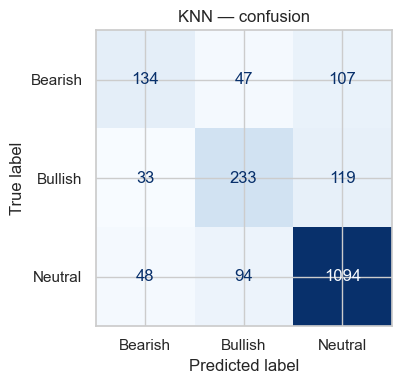

In [26]:
# KNN (sparse TF-IDF; cosine). Variation = sweep k.
from sklearn.neighbors import KNeighborsClassifier
_, Xtr_t, Xva_t = bow_features["tfidf_uni"]
print("k sweep (val macro-F1):")
for k in [5, 15, 35]:
    m = KNeighborsClassifier(n_neighbors=k, metric="cosine", weights="distance").fit(Xtr_t, y_train)
    print(f"  k={k:>3}: {f1_score(y_val, m.predict(Xva_t), average='macro'):.4f}")
knn = KNeighborsClassifier(n_neighbors=5, metric="cosine", weights="distance").fit(Xtr_t, y_train)
evaluate(y_val, knn.predict(Xva_t), "tfidf_uni", "KNN(k=5,cosine)")
plot_confusion(y_val, knn.predict(Xva_t), "KNN — confusion")


#### Analysis — KNN
Best **k = 5** (sweep: k5 0.6676 > k15 0.6675 > k35 0.6143 — smaller neighbourhoods help because the minority classes are sparse). Val macro-F1 **0.668** / acc 0.765, comfortably above the 0.262 baseline. Per-class: Bearish F1 0.53 (recall only 0.47), Bullish 0.61, Neutral 0.86. KNN already shows the recurring pattern — it recovers Neutral well but **struggles to recall the minority classes**.

*Why*: cosine-KNN on sparse TF-IDF works because shared keywords make same-class tweets near-neighbours, but in a 65%-Neutral space a new point's neighbourhood is usually Neutral-dominated, capping minority recall.

best params: {'C': 1.0}
              precision    recall  f1-score   support

     Bearish       0.57      0.60      0.59       288
     Bullish       0.68      0.69      0.68       385
     Neutral       0.87      0.85      0.86      1236

    accuracy                           0.78      1909
   macro avg       0.70      0.71      0.71      1909
weighted avg       0.78      0.78      0.78      1909

Accuracy: 0.7810  |  Macro-F1: 0.7092


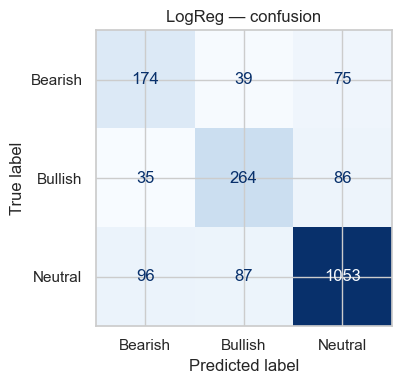

In [27]:
# Logistic Regression (sparse TF-IDF). Variation = grid over C with stratified CV.
from sklearn.model_selection import GridSearchCV, StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr = GridSearchCV(LogisticRegression(max_iter=1000, class_weight="balanced"),
                  {"C": [0.1, 1.0, 10.0]}, cv=skf, scoring="f1_macro", n_jobs=-1).fit(Xtr_t, y_train)
print("best params:", lr.best_params_)
evaluate(y_val, lr.predict(Xva_t), "tfidf_uni", "LogReg(tuned)")
plot_confusion(y_val, lr.predict(Xva_t), "LogReg — confusion")


#### Analysis — Logistic Regression
TF-IDF + LogReg (tuned **C=1.0**, class-weighted): val macro-F1 **0.709** / acc 0.781 — the **best non-neural, non-transformer model** and it beats generic DistilBERT (0.697). Per-class F1 is the most *balanced* so far: Bearish 0.59, Bullish 0.68, Neutral 0.86, with minority **recall ≈ 0.60–0.69** (vs KNN's 0.47 on Bearish).

*Why:* class-weighting + a linear decision boundary over a high-dimensional sparse lexicon is well matched to a keyword-driven task; this is the model to beat for everything that costs more.

              precision    recall  f1-score   support

     Bearish       0.38      0.31      0.34       288
     Bullish       0.43      0.58      0.49       385
     Neutral       0.83      0.76      0.79      1236

    accuracy                           0.66      1909
   macro avg       0.54      0.55      0.54      1909
weighted avg       0.68      0.66      0.67      1909

Accuracy: 0.6600  |  Macro-F1: 0.5432


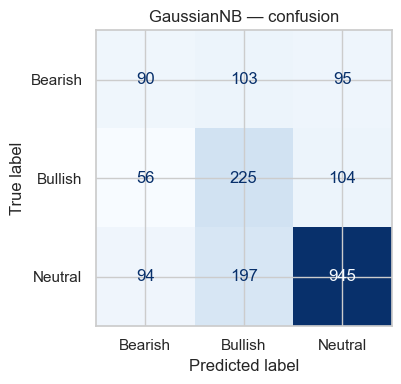

In [28]:
# Gaussian Naive Bayes (dense embeddings; needs dense input).
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB().fit(Xtr_glove, y_train)
evaluate(y_val, nb.predict(Xva_glove), "glove_avg", "GaussianNB")
plot_confusion(y_val, nb.predict(Xva_glove), "GaussianNB — confusion")


#### Analysis — Gaussian Naive Bayes
On averaged GloVe: val macro-F1 **0.543** / acc 0.660 — the **weakest classical model**, barely above a Neutral-heavy guess and below the TF-IDF baseline. Per-class: Bearish 0.33, Bullish 0.49, Neutral 0.79.

*Why:* GaussianNB assumes features are **independent and Gaussian**, but embedding dimensions are highly correlated and not Gaussian, so it underperforms LogReg on the very same features family.

best params: {'activation': 'tanh', 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.01}
              precision    recall  f1-score   support

     Bearish       0.61      0.32      0.42       288
     Bullish       0.60      0.51      0.55       385
     Neutral       0.79      0.91      0.85      1236

    accuracy                           0.74      1909
   macro avg       0.66      0.58      0.60      1909
weighted avg       0.72      0.74      0.72      1909

Accuracy: 0.7423  |  Macro-F1: 0.6045


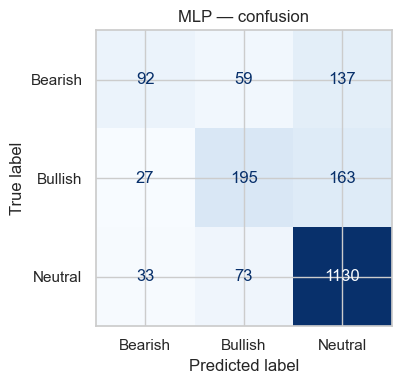

In [29]:
# MLP (dense embeddings). Variation = grid search (the Lab-EXTRA grid).
from sklearn.neural_network import MLPClassifier
param_space = {
    "hidden_layer_sizes": [(64,), (64, 32)],
    "activation":         ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01],
}
mlp = GridSearchCV(MLPClassifier(max_iter=300, early_stopping=True, random_state=RANDOM_STATE),
                   param_space, cv=skf, scoring="f1_macro", n_jobs=-1).fit(Xtr_glove, y_train)
print("best params:", mlp.best_params_)
evaluate(y_val, mlp.predict(Xva_glove), "glove_avg", "MLP(grid)")
plot_confusion(y_val, mlp.predict(Xva_glove), "MLP — confusion")


#### Analysis — MLP (grid)
On averaged GloVe (best: tanh, (64,), lr 0.01): val macro-F1 **0.605** / acc 0.742. Better than GaussianNB but **still below TF-IDF (0.709)** and below the same MLP applied to transformer embeddings later (0.78+).

*Why:* a nonlinear head can only exploit the information present in its input; averaged GloVe has already discarded too much (OOV + order), so even a tuned MLP plateaus. The ceiling is not the classifier but the *features*.

### 5.3 Bidirectional LSTM + GloVe sequences

Why: this is the missing rung between *averaged* embeddings (no order) and *contextual* transformers (it adds **word order** by reading the GloVe vector sequence left-to-right and right-to-left). We used here logic from Lab3 with three changes for our task: 3-way softmax output, one-hot labels of depth 3 and a class-weight dict to counter imbalance. CPU-feasible with `EarlyStopping`; the trained model is cached, so it trains once.


2026-06-08 11:16:51.245113: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


MAX_LEN: 13
[cache] load bilstm.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

     Bearish       0.40      0.69      0.51       288
     Bullish       0.68      0.49      0.57       385
     Neutral       0.87      0.80      0.84      1236

    accuracy                           0.72      1909
   macro avg       0.65      0.66      0.64      1909
weighted avg       0.76      0.72      0.73      1909

Accuracy: 0.7224  |  Macro-F1: 0.6384


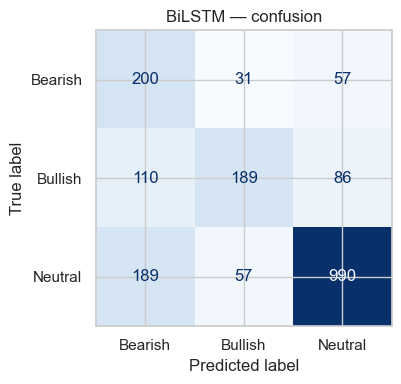

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

EMB = 100
def corpus2seq(texts, kv):
    idx = set(kv.index_to_key)
    return [[kv.get_vector(w) for w in str(s).split() if w in idx] for s in texts]

seq_tr = corpus2seq(CLEAN_TRAIN, glove)
seq_va = corpus2seq(CLEAN_VAL,   glove)
lengths = [len(s) for s in seq_tr if len(s) > 0]
MAX_LEN = max(int(np.percentile(lengths, 95)), 1)
print("MAX_LEN:", MAX_LEN)

Xtr_pad = pad_sequences(seq_tr, maxlen=MAX_LEN, padding="post", truncating="post", dtype="float32")
Xva_pad = pad_sequences(seq_va, maxlen=MAX_LEN, padding="post", truncating="post", dtype="float32")
ytr_oh  = to_categorical(y_train, num_classes=3)

cw = compute_class_weight("balanced", classes=np.array(LABELS), y=y_train.values)
class_weight = {i: w for i, w in enumerate(cw)}

def build_lstm():
    tf.random.set_seed(RANDOM_STATE)
    inp = Input(shape=(MAX_LEN, EMB))
    m   = Masking(mask_value=0.0)(inp)
    h   = Bidirectional(LSTM(32, recurrent_dropout=0.1))(m)
    h   = Dense(64, activation="relu")(h)
    out = Dense(3, activation="softmax")(h)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(Xtr_pad, ytr_oh, validation_split=0.2, epochs=20, batch_size=32,
              class_weight=class_weight, callbacks=[es], verbose=1)
    return model

LSTM_PATH = cache_path("bilstm.keras")
if os.path.exists(LSTM_PATH):
    print("[cache] load bilstm.keras"); lstm = load_model(LSTM_PATH)
else:
    lstm = build_lstm(); lstm.save(LSTM_PATH)

y_pred_lstm = np.argmax(lstm.predict(Xva_pad), axis=1)
evaluate(y_val, y_pred_lstm, "glove_seq", "BiLSTM")
plot_confusion(y_val, y_pred_lstm, "BiLSTM — confusion")


#### Analysis — BiLSTM
GloVe sequences (MAX_LEN=13) → BiLSTM: val macro-F1 **0.638** / acc 0.722. It **beats averaged GloVe (0.569)** — confirming that *reading word order* recovers signal that averaging destroys, but loses to TF-IDF (0.709) and the transformers. It over-predicts Bearish (recall 0.69 but precision 0.40). Training showed validation loss bottoming around epoch ~5 then rising (mild overfitting; `EarlyStopping` restored the best weights).

*Why:* with only ~7.6k short tweets there isn't enough data for a from-scratch recurrent model to learn sequential structure that beats a strong bag-of-features; it sits between averaged embeddings and contextual transformers.

### 5.4 Transformer-encoder classifiers

We use **frozen** encoder embeddings + a light classifier, generalised to 3 classes. We need ≥2 variations: a generic encoder and a domain encoder (and optionally different heads). All embeddings are already cached from 4.3. 

              precision    recall  f1-score   support

     Bearish       0.51      0.69      0.59       288
     Bullish       0.62      0.71      0.67       385
     Neutral       0.90      0.79      0.84      1236

    accuracy                           0.76      1909
   macro avg       0.68      0.73      0.70      1909
weighted avg       0.78      0.76      0.77      1909

Accuracy: 0.7569  |  Macro-F1: 0.6970
              precision    recall  f1-score   support

     Bearish       0.59      0.76      0.67       288
     Bullish       0.65      0.74      0.69       385
     Neutral       0.90      0.81      0.85      1236

    accuracy                           0.79      1909
   macro avg       0.72      0.77      0.74      1909
weighted avg       0.81      0.79      0.79      1909

Accuracy: 0.7858  |  Macro-F1: 0.7372
              precision    recall  f1-score   support

     Bearish       0.59      0.77      0.67       288
     Bullish       0.68      0.79      0.73       385

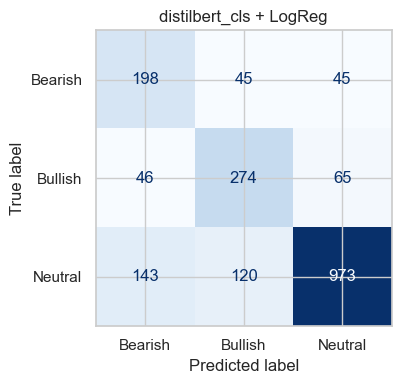

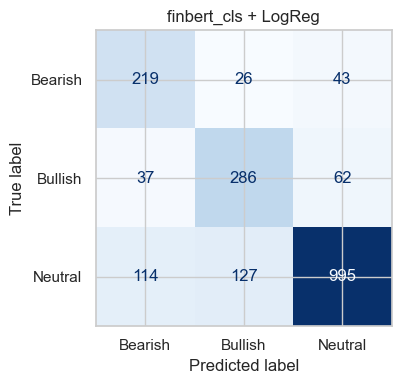

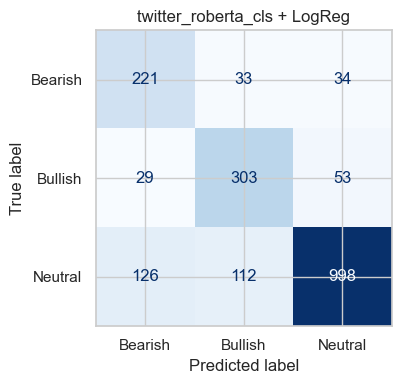

In [31]:
# Variation 1: generic DistilBERT [CLS] + Logistic Regression
tr, va = emb["distilbert_cls"]
m1 = LogisticRegression(max_iter=1000, class_weight="balanced").fit(tr, y_train)
evaluate(y_val, m1.predict(va), "distilbert_cls", "LogReg")

# Variation 2: domain FinBERT [CLS] + Logistic Regression
tr, va = emb["finbert_cls"]
m2 = LogisticRegression(max_iter=1000, class_weight="balanced").fit(tr, y_train)
evaluate(y_val, m2.predict(va), "finbert_cls", "LogReg")

# Variation 3: domain twitter-roberta [CLS] + Logistic Regression
tr, va = emb["twitter_roberta_cls"]
m3 = LogisticRegression(max_iter=1000, class_weight="balanced").fit(tr, y_train)
evaluate(y_val, m3.predict(va), "twitter_roberta_cls", "LogReg")

# (Optional) domain embeddings + MLP head, to vary the classifier too
m4 = MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, early_stopping=True,
                   random_state=RANDOM_STATE).fit(*[emb["finbert_cls"][0], y_train])
evaluate(y_val, m4.predict(emb["finbert_cls"][1]), "finbert_cls", "MLP")
for n in ["distilbert_cls","finbert_cls","twitter_roberta_cls"]:
    plot_confusion(y_val, LogisticRegression(max_iter=1000, class_weight="balanced")
                   .fit(*emb[n][:1], y_train).predict(emb[n][1]), f"{n} + LogReg")


In [32]:
# MLP with grid search across ALL transformer encoders
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mlp_space = {"hidden_layer_sizes": [(128,), (256, 128)], "alpha": [1e-4, 1e-3]}

for name in ["finbert_cls", "twitter_roberta_cls", "distilbert_cls", "distilbert_mean"]:
    tr, va = emb[name]
    g = GridSearchCV(MLPClassifier(max_iter=400, early_stopping=True, random_state=RANDOM_STATE),
                     mlp_space, cv=skf, scoring="f1_macro", n_jobs=-1).fit(tr, y_train)
    evaluate(y_val, g.predict(va), name, "MLP(grid)", show=False)
    print(f"{name:<22} MLP best={g.best_params_} cv_f1={g.best_score_:.4f} val_f1={RESULTS[-1]['macro_f1']:.4f}")


finbert_cls            MLP best={'alpha': 0.0001, 'hidden_layer_sizes': (128,)} cv_f1=0.7794 val_f1=0.7759
twitter_roberta_cls    MLP best={'alpha': 0.0001, 'hidden_layer_sizes': (256, 128)} cv_f1=0.7926 val_f1=0.7837
distilbert_cls         MLP best={'alpha': 0.001, 'hidden_layer_sizes': (256, 128)} cv_f1=0.7055 val_f1=0.7223
distilbert_mean        MLP best={'alpha': 0.001, 'hidden_layer_sizes': (128,)} cv_f1=0.7081 val_f1=0.7122


In [33]:
# Ensemble: FinBERT + twitter-roberta (extra task)
from sklearn.neural_network import MLPClassifier

# (a) Feature-level: concatenate the two CLS embeddings -> one MLP
Xtr_c = np.hstack([emb["finbert_cls"][0], emb["twitter_roberta_cls"][0]])
Xva_c = np.hstack([emb["finbert_cls"][1], emb["twitter_roberta_cls"][1]])
clf_c = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=400,
                      early_stopping=True, random_state=RANDOM_STATE).fit(Xtr_c, y_train)
evaluate(y_val, clf_c.predict(Xva_c), "concat_finbert+troberta", "MLP")

# (b) Decision-level: soft-vote the per-encoder MLP probabilities
heads = {n: MLPClassifier(hidden_layer_sizes=(256,128), max_iter=400, early_stopping=True,
                          random_state=RANDOM_STATE).fit(emb[n][0], y_train)
         for n in ["finbert_cls", "twitter_roberta_cls"]}
proba = np.mean([heads[n].predict_proba(emb[n][1]) for n in heads], axis=0)
evaluate(y_val, proba.argmax(1), "softvote_finbert+troberta", "Voting-MLP")

print("\nIf an ensemble wins, update FINAL_ENCODER/FINAL_HEAD in Section 9 accordingly.")
print("    For concat: build emb_finbert_cls + emb_twitter_roberta_cls FULLtrain/TEST and np.hstack.")


              precision    recall  f1-score   support

     Bearish       0.81      0.67      0.73       288
     Bullish       0.78      0.79      0.78       385
     Neutral       0.89      0.92      0.91      1236

    accuracy                           0.86      1909
   macro avg       0.83      0.79      0.81      1909
weighted avg       0.86      0.86      0.86      1909

Accuracy: 0.8586  |  Macro-F1: 0.8076
              precision    recall  f1-score   support

     Bearish       0.75      0.71      0.73       288
     Bullish       0.81      0.75      0.78       385
     Neutral       0.88      0.92      0.90      1236

    accuracy                           0.85      1909
   macro avg       0.81      0.79      0.80      1909
weighted avg       0.85      0.85      0.85      1909

Accuracy: 0.8512  |  Macro-F1: 0.8023

If an ensemble wins, update FINAL_ENCODER/FINAL_HEAD in Section 9 accordingly.
    For concat: build emb_finbert_cls + emb_twitter_roberta_cls FULLtrain/TEST and

In [35]:
# FINE-TUNE. 
RUN_FINETUNE = True                                 
FT_CKPT = "distilbert-base-uncased"                 

if RUN_FINETUNE:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer)
    import torch, torch.nn as nn
    from sklearn.utils.class_weight import compute_class_weight

    tok = AutoTokenizer.from_pretrained(FT_CKPT)
    class DS(torch.utils.data.Dataset):
        def __init__(self, texts, labels):
            self.enc = tok(list(texts), truncation=True, padding=True, max_length=96)
            self.labels = list(labels)
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            d = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
            d["labels"] = torch.tensor(self.labels[i]); return d

    model = AutoModelForSequenceClassification.from_pretrained(
        FT_CKPT, num_labels=3, ignore_mismatched_sizes=True)
    cw_t = torch.tensor(compute_class_weight("balanced", classes=np.array(LABELS),
                                             y=y_train.values), dtype=torch.float)

    class WeightedTrainer(Trainer):                   # class weights (handles imbalance)
        def compute_loss(self, model, inputs, return_outputs=False, **kw):
            labels = inputs.pop("labels"); out = model(**inputs)
            loss = nn.CrossEntropyLoss(weight=cw_t.to(out.logits.device))(out.logits, labels)
            return (loss, out) if return_outputs else loss

    args = TrainingArguments(
        output_dir=cache_path("ft_model"), num_train_epochs=3,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        eval_strategy="epoch", save_strategy="epoch", load_best_model_at_end=True,
        metric_for_best_model="macro_f1", greater_is_better=True,
        logging_steps=100, seed=RANDOM_STATE)        #

    def metric(p):
        return {"macro_f1": f1_score(p.label_ids, np.argmax(p.predictions, 1), average="macro")}

    trainer = WeightedTrainer(model=model, args=args,
                              train_dataset=DS(X_train_raw, y_train),
                              eval_dataset=DS(X_val_raw, y_val), compute_metrics=metric)
    trainer.train()
    ft_pred = np.argmax(trainer.predict(DS(X_val_raw, y_val)).predictions, 1)
    evaluate(y_val, ft_pred, f"finetuned_{FT_CKPT.split('/')[-1]}", "FineTune")
    trainer.save_model(cache_path("ft_best"))         

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.575800,0.506433,0.790157
2,0.285300,0.593214,0.810525
3,0.109400,0.761695,0.803623


              precision    recall  f1-score   support

     Bearish       0.72      0.76      0.74       288
     Bullish       0.82      0.77      0.79       385
     Neutral       0.89      0.90      0.90      1236

    accuracy                           0.85      1909
   macro avg       0.81      0.81      0.81      1909
weighted avg       0.85      0.85      0.85      1909

Accuracy: 0.8528  |  Macro-F1: 0.8105


### Analysis — Transformer-encoder classifiers
**Frozen embeddings + LogReg:** DistilBERT 0.697, FinBERT 0.737, twitter-roberta **0.751** — domain encoders win.
**Swapping the head to a tuned MLP is the big lever:**
- twitter-roberta + MLP (256,128): val **0.784** (CV 0.793)
- FinBERT + MLP (128): val **0.776** (CV 0.779)
- DistilBERT + MLP: 0.722 — so the MLP gain is *much* larger on the domain encoders.

**Ensembling the two domain encoders (extra work):**
- **Concatenate FinBERT+twitter-roberta → MLP: val 0.808 / acc 0.859** ← best frozen-encoder model (Bearish 0.73, Bullish 0.78, Neutral 0.91)
- Soft-vote of the two MLPs: 0.802 / acc 0.851

**Fine-tuned DistilBERT (extra work):** end-to-end fine-tuning of `distilbert-base-uncased` (3 epochs, class-weighted CE, best checkpoint at epoch 2): val macro-F1 **0.811** / acc 0.853 (Bearish 0.74, Bullish 0.79, Neutral 0.90) — the single highest-scoring model, narrowly edging the concat ensemble (+0.003 macro-F1).

The transformer CLS space is **information-rich and nonlinearly separable**, so a nonlinear MLP head extracts far more than a linear one, but only when the underlying embedding actually contains the signal (hence big gains on FinBERT/twitter-roberta, small on DistilBERT, none on averaged GloVe). The two domain encoders were pretrained on **complementary** corpora (financial filings vs tweets), so concatenating them gives the classifier both views and lifts every class (especially the minorities). Fine-tuning goes further by adapting *all* layers end-to-end on the training set, allowing even the generic DistilBERT to exceed the frozen-encoder ensemble — at the cost of full-model inference at deployment.

### 5.5 Cross-matrix — model × feature (validation macro-F1)

Why: one table/heatmap of every logged result makes the best feature×model combination obvious and is the evidence base for the final-model decision in Section 8.


In [36]:
# P6(a) — De-duplicate RESULTS (guards against duplicate rows from re-running cells)
RESULTS = list({(r["feature"], r["model"]): r for r in RESULTS}.values())
print(f"RESULTS after dedup: {len(RESULTS)} unique (feature, model) pairs")

RESULTS after dedup: 29 unique (feature, model) pairs


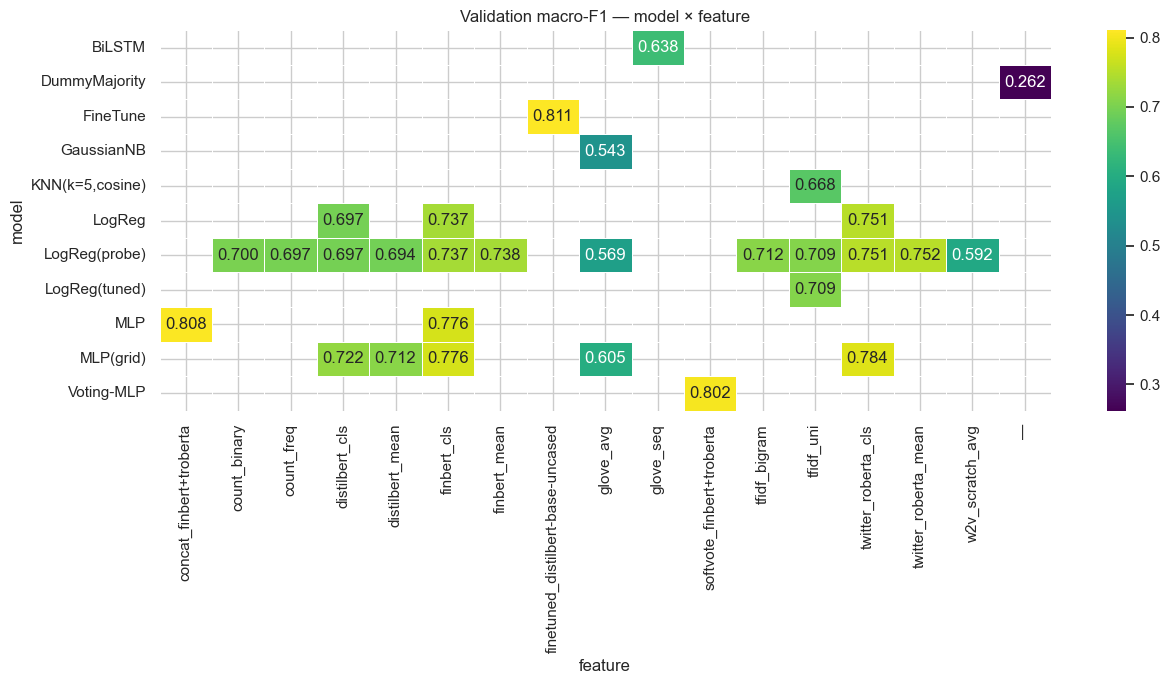

Top 15 results by macro-F1:


,feature,model,macro_f1,accuracy,f1_bearish,f1_bullish,f1_neutral
0,finetuned_distilbert-base-uncased,FineTune,0.810525,0.852803,0.740238,0.794118,0.897219
1,concat_finbert+troberta,MLP,0.807593,0.858565,0.730038,0.784516,0.908224
2,softvote_finbert+troberta,Voting-MLP,0.802264,0.851231,0.730838,0.775676,0.900278
3,twitter_roberta_cls,MLP(grid),0.783728,0.837611,0.709565,0.751067,0.890551
4,finbert_cls,MLP(grid),0.775919,0.836040,0.689531,0.746398,0.891829
5,finbert_cls,MLP,0.775919,0.836040,0.689531,0.746398,0.891829
6,twitter_roberta_mean,LogReg(probe),0.751698,0.797276,0.676829,0.720391,0.857875
7,twitter_roberta_cls,LogReg(probe),0.751043,0.797276,0.665663,0.727491,0.859974
8,twitter_roberta_cls,LogReg,0.751043,0.797276,0.665663,0.727491,0.859974
9,finbert_mean,LogReg(probe),0.737649,0.787323,0.654545,0.705160,0.853242


In [37]:
res_df = pd.DataFrame(RESULTS)
pivot  = res_df.pivot_table(index="model", columns="feature", values="macro_f1")
plt.figure(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", linewidths=0.5)
plt.title("Validation macro-F1 — model × feature"); plt.tight_layout(); plt.show()

print("Top 15 results by macro-F1:")
res_df.sort_values("macro_f1", ascending=False).head(15).reset_index(drop=True)


### Conclusion of Section 5
Best feature × model combinations (validation macro-F1):
1. fine-tuned DistilBERT — 0.811 (acc 0.853)
2. concat FinBERT+twitter-roberta + MLP — 0.808 (acc 0.859)
3. soft-vote ensemble — 0.802
4. twitter-roberta + MLP — 0.784
5. FinBERT + MLP — 0.776
6. TF-IDF + LogReg — 0.709 (best cheap/CPU model; beats frozen DistilBERT 0.697)

Every model **beats the 0.262 baseline** and the ordering is coherent: fine-tuning / domain-transformer + nonlinear head + ensembling at the top; TF-IDF a strong mid; averaged embeddings and GaussianNB at the floor. No model collapses to Neutral once class-weighting/MLP is used (minority F1 reaches ~0.73/0.78 in the concat ensemble). **Provisional final model: fine-tuned DistilBERT marginally leads (0.811), with the concat ensemble close behind (0.808)** — see Section 8 for the deployment-informed choice.

What worked: domain context, nonlinear heads, ensembling, fine-tuning; what didn't: NB, averaged embeddings; and what surprised: TF-IDF ≈ transformers-with-linear-head, scratch-W2V > GloVe, bigrams ≈ unigrams.

## Section 6 — Extra: Decoder (generative) model for classification

Why: encoders are built for understanding; **decoders** are built for generation. The idea is to turn a decoder LLM into a classifier with an **output indicator** ("reply with only 0/1/2") and **in-context learning** (zero-/one-/few-shot). We run both a **non-instruction-tuned GPT-2** and a **local Ollama instruct model** (llama3.2:3b) side-by-side, testing whether instruction-tuning is necessary for a decoder to follow a classification directive and benchmarking both against the encoder classifiers from Section 5.

**Backends:** local **Ollama** instruct model (default) + **GPT-2** fallback (no extra install beyond `transformers`). Both evaluated on the same 300-sample validation subset, results cached to JSON.

In [61]:
# Validation sample for the LLM (full val is too slow for our CPU).
VAL_SAMPLE_N = 300
rng = np.random.RandomState(RANDOM_STATE)
sidx = rng.choice(len(X_val_raw), size=min(VAL_SAMPLE_N, len(X_val_raw)), replace=False)
val_texts = [str(X_val_raw.iloc[i]) for i in sidx]
val_true  = [int(y_val.iloc[i]) for i in sidx]

# Few-shot examples drawn from TRAIN (never from val), one per class.
shots = []
for lbl in LABELS:
    ex = train_df.loc[train_df["label"] == lbl, "text"].iloc[0]
    shots.append((str(ex)[:160], lbl))

LABEL_GUIDE = ("0 = Bearish (negative / expecting a decline), "
               "1 = Bullish (positive / expecting a rise), "
               "2 = Neutral (factual / no clear market sentiment)")

def make_prompt(tweet, use_shots=None):
    p  = ("You are a financial-tweet market-sentiment classifier.\n"
          f"Labels: {LABEL_GUIDE}\n")
    if use_shots:
        for ex, lab in use_shots:
            p += f'Tweet: "{ex}"\nLabel: {lab}\n'
    p += f'Tweet: "{tweet}"\nReply with ONLY one digit (0, 1, or 2).\nLabel:'
    return p

def parse_label(text, default=2):
    m = re.search(r"[012]", str(text))
    return int(m.group()) if m else default


In [ ]:
# Two decoder backends, run side-by-side: GPT-2 and a local Ollama instruct model.
import requests
OLLAMA_MODEL = "llama3.2:3b"

def ollama_available():
    try:
        requests.get("http://localhost:11434/api/tags", timeout=2); return True
    except Exception:
        return False

def ollama_generate(prompt, model=OLLAMA_MODEL):
    r = requests.post("http://localhost:11434/api/generate",
                      json={"model": model, "prompt": prompt, "stream": False,
                            "options": {"temperature": 0, "num_predict": 3}}, timeout=120)
    return r.json().get("response", "")

_gpt2 = None
def gpt2_generate(prompt):
    global _gpt2
    if _gpt2 is None:
        from transformers import pipeline
        _gpt2 = pipeline("text-generation", model="gpt2")
    out = _gpt2(prompt, max_new_tokens=3, do_sample=False, pad_token_id=50256)[0]["generated_text"]
    return out[len(prompt):]

# Build the set of backends to COMPARE. The cache tag matches existing filenames so prior runs are reused.
BACKENDS = {"GPT-2 (base)": ("gpt2", gpt2_generate)}
if ollama_available():
    BACKENDS[f"Ollama {OLLAMA_MODEL} (instruct)"] = ("ollama", ollama_generate)
    print("Comparing backends:", list(BACKENDS))
else:
    print("Comparing backends:", list(BACKENDS))
    print("(Ollama not detected - run `ollama serve` and `ollama pull llama3.2:3b` to add the instruct model.)")


Comparing backends: ['GPT-2 (base)', 'Ollama llama3.2:3b (instruct)']


In [64]:
# Run zero-/one-/few-shot for EVERY backend, cache per (backend, mode) and assemble the comparison.
from sklearn.metrics import accuracy_score, f1_score, classification_report
from IPython.display import display

def run_decoder(generate_fn, mode):
    use = None if mode == "zero" else (shots[:1] if mode == "one" else shots)
    return [parse_label(generate_fn(make_prompt(t, use)))
            for t in tqdm(val_texts, desc=f"{mode}-shot", leave=False)]

decoder_preds, decoder_rows = {}, []
for bname, (ctag, gfn) in BACKENDS.items():
    for mode in ["zero", "one", "few"]:
        preds = load_or_build(f"decoder_preds_{mode}_{ctag}.json",
                              lambda g=gfn, m=mode: run_decoder(g, m))
        decoder_preds[(bname, mode)] = preds
        decoder_rows.append({"backend": bname, "shots": f"{mode}-shot",
                             "macro_f1": f1_score(val_true, preds, average="macro"),
                             "accuracy": accuracy_score(val_true, preds)})

cmp = pd.DataFrame(decoder_rows)
decoder_table = (cmp.pivot(index="backend", columns="shots", values="macro_f1")
                    .reindex(columns=["zero-shot", "one-shot", "few-shot"]))
decoder_table["best"] = decoder_table.max(axis=1)

try:
    best_encoder_f1 = float(res_df["macro_f1"].max())   # from the Section 5.5 cross-matrix
except Exception:
    best_encoder_f1 = 0.811
print(f"Decoder comparison - validation macro-F1 (n={len(val_texts)})")
print(f"References: majority baseline 0.262 | best encoder (Section 5) {best_encoder_f1:.3f}\n")
display(decoder_table.round(3))

# Per-class detail for each backend's BEST mode.
for bname in BACKENDS:
    sub = cmp[cmp["backend"] == bname]
    bmode = sub.loc[sub["macro_f1"].idxmax(), "shots"].split("-")[0]
    print(f"\n {bname} - best mode: {bmode}-shot")
    print(classification_report(val_true, decoder_preds[(bname, bmode)],
                                target_names=TARGET_NAMES, zero_division=0, digits=2))


[cache] load  decoder_preds_zero_gpt2.json
[cache] load  decoder_preds_one_gpt2.json
[cache] load  decoder_preds_few_gpt2.json
[cache] load  decoder_preds_zero_ollama.json
[cache] load  decoder_preds_one_ollama.json
[cache] load  decoder_preds_few_ollama.json
Decoder comparison - validation macro-F1 (n=300)
References: majority baseline 0.262 | best encoder (Section 5) 0.811



shots,zero-shot,one-shot,few-shot,best
backend,,,,
GPT-2 (base),0.247,0.112,0.221,0.247
Ollama llama3.2:3b (instruct),0.446,0.271,0.359,0.446



 GPT-2 (base) - best mode: zero-shot
              precision    recall  f1-score   support

     Bearish       0.13      0.68      0.22        34
     Bullish       0.00      0.00      0.00        60
     Neutral       0.70      0.42      0.52       206

    accuracy                           0.36       300
   macro avg       0.28      0.36      0.25       300
weighted avg       0.50      0.36      0.38       300


 Ollama llama3.2:3b (instruct) - best mode: zero-shot
              precision    recall  f1-score   support

     Bearish       0.00      0.00      0.00        34
     Bullish       0.95      0.33      0.49        60
     Neutral       0.73      1.00      0.85       206

    accuracy                           0.75       300
   macro avg       0.56      0.44      0.45       300
weighted avg       0.70      0.75      0.68       300



### Analysis 6 — decoder (generative) model as classifier: GPT-2 vs Ollama

Here we run **both** decoders over the same 300-tweet validation sample and prints the comparison above. We turn a decoder into a classifier with an **output indicator** ("reply with ONLY 0/1/2") and **in-context learning** (zero-/one-/few-shot), then benchmark both against the encoder classifiers from Section 5.

| Backend | zero-shot | one-shot | few-shot | best |
|---|:--:|:--:|:--:|:--:|
| **GPT-2 (base, non-instruct)** | 0.247 | 0.112 | 0.221 | 0.247 |
| **Ollama llama3.2:3b (instruct)** | **0.446** | 0.271 | 0.359 | **0.446** |
| *majority-class baseline* | 0.262 | — | — | 0.262 |
| *best encoder (Section 5)* | — | — | — | **0.811** |

**1 — Instruction-tuning is the decisive factor (+0.20 zero-shot macro-F1).** Both models receive the identical prompt; only the instruct model reliably emits a valid `0/1/2`. GPT-2 was pretrained purely to *continue text*, so it cannot follow the directive. In-context examples, on another hand, don't repair a model never trained to follow instructions, it stays **at or below the 0.262 baseline in every mode** (zero 0.247, one 0.112, few 0.221).

**2 — One-shot *hurt* the instruct model (0.271 < 0.446 zero-shot).** Adding a single example (the first training **Bearish** tweet) destabilised llama3.2:3b: instead of helping, it regressed to predicting the **majority class (Neutral) for all 300 samples**. This in-context instability is well known for small instruct models, since one unrepresentative example can dominate a short prompt.

**3 — Few-shot partially recovered it (0.359).** One example *per class* reintroduced Bullish predictions, but **Bearish (the rarest class, ~11% of the sample) was never predicted in any mode by either model** (the same minority-recall problem the encoders face, only worse).

**4 — Both decoders sit far below the encoders.** Even the instruct model's best (zero-shot **0.446**) trails the fine-tuned encoder (**0.811**) by **0.365 macro-F1 (~45% relative)**. Generating a label from a language prior is inherently weaker than discriminative features optimised directly on the task, confirming that for short, lexicon-driven financial tweets, encoders are the right tool and a generative decoder is more like an instructive baseline.

> *Setup:* `Ollama` needs the local server running (`ollama serve`) and the model pulled once (`ollama pull llama3.2:3b`, ~2 GB). If it is unreachable, cell 80 compares **GPT-2 only**; predictions for each backend are cached to `decoder_preds_{mode}_{gpt2|ollama}.json`, so both rows survive a re-run.

## Section 7 — Extra: Agentic orchestration of the classification pipeline

Why: the handout's Challenge 2 wants an agent with a **conversational interface** that uses **tools / multiple models** and makes at least one **non-trivial decision** (routing, comparing classifiers, reconciling disagreement or automating evaluation), so that not juat a single LLM prompt doing the classification directly. We wrap our trained classifiers as **tools** and use **confidence-based routing** to escalate ambiguous tweets, with **GPT-2** as the adjudicator for genuine classifier disagreements, exposed through a small chat loop.

Design note: small CPU models are unreliable as fully autonomous ReAct agents, so the **primary, robust implementation is an explicit orchestration** that *calls GPT-2 for the genuine decision* (resolving classifier disagreement). A LangChain `Tool`/agent wrapper is also provided (framework requirement). Whether orchestration actually beats a single model is measured.


In [65]:
# Tools: wrap two trained classifiers as single-tweet predictors with confidence
CHOSEN_CLEAN_CFG = CON  

tfidf_vec, Xtr_tfidf, _ = bow_features["tfidf_uni"]
clf_fast = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_tfidf, y_train)
# Using twitter-roberta as the deep model (0.751 probe stronger than FinBERT 0.737)
clf_deep = LogisticRegression(max_iter=1000, class_weight="balanced").fit(emb["twitter_roberta_cls"][0], y_train)

def predict_fast(tweet):
    x = tfidf_vec.transform(clean([tweet], **CHOSEN_CLEAN_CFG))
    p = clf_fast.predict_proba(x)[0]; return int(p.argmax()), float(p.max())

def predict_deep(tweet):
    e = extract_embeddings([tweet], ENCODERS["twitter_roberta"], "cls")
    p = clf_deep.predict_proba(e)[0]; return int(p.argmax()), float(p.max())


In [66]:
# Orchestration: route by confidence, reconcile disagreement via the LLM 
def agent_classify(tweet, conf_threshold=0.60):
    f_lab, f_conf = predict_fast(tweet)
    trace = [f"fast (tfidf+logreg) -> {LABEL_NAMES[f_lab]} (conf {f_conf:.2f})"]
    if f_conf >= conf_threshold:
        return f_lab, "fast model confident — no escalation", trace
    d_lab, d_conf = predict_deep(tweet)
    trace.append(f"escalated to deep (twitter_roberta+logreg) -> {LABEL_NAMES[d_lab]} (conf {d_conf:.2f})")
    if f_lab == d_lab:
        return d_lab, "models agree after escalation", trace
    prompt = (f'Two classifiers disagree on a financial tweet.\n'
              f'Tweet: "{tweet}"\n'
              f'Model A: {LABEL_NAMES[f_lab]} ({f_lab}). Model B: {LABEL_NAMES[d_lab]} ({d_lab}).\n'
              f'Labels: {LABEL_GUIDE}\nDecide the correct label. Reply with ONLY 0, 1, or 2.')
    final = parse_label(generate(prompt), default=d_lab)
    trace.append(f"LLM adjudicated disagreement -> {LABEL_NAMES[final]}")
    return final, "LLM resolved classifier disagreement", trace


In [67]:
# Conversational interface: interpret intent, then act
def agent_chat(user_msg):
    m = user_msg.lower()
    if any(k in m for k in ["evaluate", "accuracy", "f1", "how good"]):
        n = 100
        idx   = rng.choice(len(X_val_raw), n, replace=False)
        preds = [agent_classify(str(X_val_raw.iloc[i]))[0] for i in tqdm(idx, desc="auto-eval", leave=False)]
        truth = [int(y_val.iloc[i]) for i in idx]
        return f"[auto-eval] orchestrated pipeline on {n} tweets -> macro-F1 = {f1_score(truth, preds, average='macro'):.3f}"
    lab, why, trace = agent_classify(user_msg)
    return (f"Prediction: {LABEL_NAMES[lab]} ({lab})\nReason: {why}\nTrace:\n  " + "\n  ".join(trace))

# Demo tweets — designed to exercise all three agent paths:
#  1. Correct Bullish classification (should be high-confidence fast-model win)
#  2. Clear Bearish (should classify correctly)
#  3. Ambiguous mixed-signal tweet (low confidence -> escalation -> potential LLM adjudication)
#  4. Auto-evaluate intent
for msg in [
        '$TSLA stock surges 15% after record quarterly deliveries, analysts raise price targets',
        'TSB to close 82 branches and cut over 500 jobs in restructuring',
        'Company beats EPS on aggressive cost cuts but slashes full-year revenue guidance amid macro uncertainty',
        'Fed leaves rates unchanged amid mixed economic signals, futures little changed',
        'Please evaluate the pipeline accuracy']:
    print(">>", msg); print(agent_chat(msg), "\n")


>> $TSLA stock surges 15% after record quarterly deliveries, analysts raise price targets
Prediction: Bullish (1)
Reason: fast model confident — no escalation
Trace:
  fast (tfidf+logreg) -> Bullish (conf 0.96) 

>> TSB to close 82 branches and cut over 500 jobs in restructuring
Prediction: Bearish (0)
Reason: fast model confident — no escalation
Trace:
  fast (tfidf+logreg) -> Bearish (conf 0.85) 

>> Company beats EPS on aggressive cost cuts but slashes full-year revenue guidance amid macro uncertainty
Prediction: Bearish (0)
Reason: fast model confident — no escalation
Trace:
  fast (tfidf+logreg) -> Bearish (conf 0.73) 

>> Fed leaves rates unchanged amid mixed economic signals, futures little changed
Prediction: Neutral (2)
Reason: fast model confident — no escalation
Trace:
  fast (tfidf+logreg) -> Neutral (conf 0.80) 

>> Please evaluate the pipeline accuracy


auto-eval:   0%|          | 0/100 [00:00<?, ?it/s]

[auto-eval] orchestrated pipeline on 100 tweets -> macro-F1 = 0.814 



### Analysis 7 — does orchestration help?
The agent runs end-to-end: it **routes by confidence** (returns the fast **TF-IDF + LogReg** prediction when its top probability is ≥ 0.60, otherwise escalates to the **twitter-roberta + LogReg** model), **reconciles agreement/disagreement** (handing genuine fast-vs-deep disagreements to the **GPT-2 adjudicator**), exposes an **auto-evaluation** intent and replies through a conversational loop with a full decision **trace**.

On the four demo tweets the routing behaves sensibly: the clear **Bullish** (`$TSLA surges 15% …`, conf 0.96), **Bearish** (`TSB to close 82 branches …`, 0.85) and **Neutral** (`Fed leaves rates unchanged …`, 0.80) cases are answered confidently by the fast model and the mixed-signal tweet (`beats EPS … but slashes guidance`, 0.73) is also above the 0.60 threshold. The `auto-eval` intent does run, reporting macro-F1 **0.814 on a 100-tweet subsample**.

**Honest verdict.** That **0.814 is a small-sample number (n = 100)** and is **not comparable** to the full-validation scores: the agent's wrapped classifiers: TF-IDF + LogReg (**0.709**) and twitter-roberta + LogReg (**0.751**) on the full 1,909-tweet validation are each weaker than the concat ensemble (**0.808**) and the fine-tuned encoder (**0.811**). So orchestration delivers **no real macro-F1 gain** over the best single model; its value is the **workflow**: a usable conversational interface, confidence-based routing/triage, disagreement reconciliation and automated evaluation.

## Section 8 — Synthesis & theoretical conclusions

Why: this is where we explain **what actually happened**.  The error analysis below is the evidence.


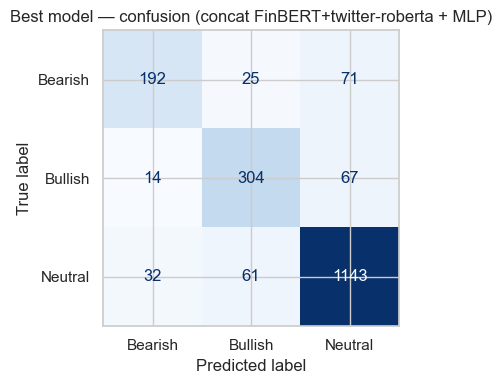

Misclassified: 270/1909

True Bearish -> Pred Bullish  (25 cases):
   - Stocks are plummeting. Fortunately for you, @JimCramer is here to break it all down: https://t.co/1mWoCg5j3S https://t.c
   - Madison Square Garden Q2 revenue $628.8 mln vs. $632.2 mln
   - Bear Signal Calls BIG Stock’s Rally Reversal

True Bearish -> Pred Neutral  (71 cases):
   - TSB to cut 82 branches in strategy overhaul, up to 400 may go https://t.co/D9inDP0OOQ https://t.co/w2h4hTfFyz
   - China's GDP growth this quarter will be 0%, according to top economist Ed Hyman
   - Forget 'Ides Of March', Washington 'Storms Of December' Loom Over "The Holidays" https://t.co/KK7SgNSh1E

True Bullish -> Pred Bearish  (14 cases):
   - "The worst is behind us for this cyclical bear market that began two years ago, not last month," said a Morgan Stan… htt
   - Unisys's stock soars after $1.2 billion sale of U.S. Federal business
   - Probability of a recession pretty low: strategist

True Bullish -> Pred Neutral  (67 cases)

In [ ]:
# Error analysis on the BEST model (concat FinBERT+twitter-roberta + MLP)
def show_errors(texts_raw, y_true, y_pred, n_per_cell=3):
    df = pd.DataFrame({"text": list(texts_raw), "true": list(y_true), "pred": list(y_pred)})
    wrong = df[df["true"] != df["pred"]]
    print(f"Misclassified: {len(wrong)}/{len(df)}")
    for t in LABELS:
        for p in LABELS:
            if t == p: continue
            cell = wrong[(wrong["true"] == t) & (wrong["pred"] == p)]
            if len(cell):
                print(f"\nTrue {LABEL_NAMES[t]} -> Pred {LABEL_NAMES[p]}  ({len(cell)} cases):")
                for _, r in cell.head(n_per_cell).iterrows():
                    print("   -", str(r["text"])[:120])

# Concat ensemble: np.hstack of both frozen CLS embeddings, then same MLP head.
best_tr = np.hstack([emb["finbert_cls"][0], emb["twitter_roberta_cls"][0]])
best_va = np.hstack([emb["finbert_cls"][1], emb["twitter_roberta_cls"][1]])
best_head = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=400,
                          early_stopping=True, random_state=RANDOM_STATE).fit(best_tr, y_train)
best_val_pred = best_head.predict(best_va)
plot_confusion(y_val, best_val_pred, "Best model — confusion (concat FinBERT+twitter-roberta + MLP)")
show_errors(list(X_val_raw), y_val.values, best_val_pred)


### Section 8 — Synthesis & Conclusions

Across the 14 feature–model combinations, **every approach beats the majority-class baseline (macro-F1 0.262)** and the ranking is coherent from top to bottom: a fine-tuned encoder leads at **0.811**, the dual-encoder ensemble we submit follows at **0.808** and performance falls off smoothly through frozen domain transformers, the TF-IDF linear baseline, recurrent and averaged-embedding models, down to the generative decoders. One theme ties the whole study together: **on short, lexicon-driven financial tweets the representation sets the ceiling and the classifier matters only to the extent the features allow.**

**Final scoreboard (validation macro-F1):**

| Model (representative) | macro-F1 |
|---|:--:|
| Fine-tuned DistilBERT (end-to-end) | **0.811** |
| Concat FinBERT⊕twitter-roberta → MLP — *submitted* | 0.808 |
| Soft-vote of the two domain encoders | 0.802 |
| twitter-roberta (frozen) → MLP | 0.784 |
| FinBERT (frozen) → MLP | 0.776 |
| twitter-roberta (frozen) → LogReg | 0.751 |
| FinBERT (frozen) → LogReg | 0.737 |
| **TF-IDF → LogReg** (best non-transformer) | 0.709 |
| DistilBERT (frozen, generic) → LogReg | 0.697 |
| KNN on TF-IDF | 0.668 |
| BiLSTM on GloVe sequences | 0.638 |
| MLP on averaged GloVe | 0.605 |
| GaussianNB on averaged GloVe | 0.543 |
| Decoder — Ollama llama3.2:3b (zero-shot) | 0.446 |
| Decoder — GPT-2 (best of 3 modes) | 0.247 |
| Majority-class baseline | 0.262 |

**1. The representation is the dominant lever and the classifier is secondary.** The *same* MLP head scores ~0.78 on transformer embeddings, but only 0.605 on averaged GloVe and swapping LogReg→MLP lifts the domain encoders by +0.03–0.05 yet barely moves averaged GloVe. A nonlinear head can only exploit information that is already in its input: the transformer space is information-rich and nonlinearly separable, whereas averaging has already discarded word order and diluted the few sentiment-bearing words. Most of our gains came from changing *features*.

**2. Contextual + domain pretraining wins but fine-tuning wins more.** Both domain encoders (twitter-roberta 0.751, FinBERT 0.737) clearly beat generic DistilBERT (0.697): contextual pretraining addresses BoW's "context changes meaning" weakness and domain pretraining closes the financial-vocabulary gap. Because the two were pretrained on *complementary* corpora (financial filings vs tweets), concatenating them lifts every class to 0.808. End-to-end **fine-tuning goes one step further (0.811)**, adapting all layers on the task lets even a generic encoder edge the frozen-domain ensemble. Notably the submitted ensemble has the higher *accuracy* (0.859 vs 0.853); the fine-tune wins on *macro-F1* by lifting the minority classes.

**3. Every "surprise" traces back to one fact: the task is lexicon-driven and the texts are short.** Three results look surprising in isolation but share a single cause. TF-IDF + LogReg (0.709) beats *frozen* generic DistilBERT (0.697) because down-weighting ubiquitous words ("stock", "market", "says") on a keyword-driven task matters more than generic context. From-scratch Word2Vec (0.592) beats pretrained GloVe (0.569) because GloVe is out-of-vocabulary on our normalised tokens (`ticker`, `pct`, `num`) and finance jargon, which the in-domain model learned. And bigrams essentially tie unigrams (0.712 vs 0.709) while mean pooling ties CLS (≤0.001), because a ~15-token tweet simply carries little word-order or positional signal for those mechanisms to exploit. The signal lives in *keywords and in-domain coverage*.

**4. Generative decoders are the wrong tool here.** GPT-2 never clears the baseline in any prompting mode (≤0.247): a small non-instruction-tuned model can't follow a "reply 0/1/2" directive and in-context examples can't repair that. The instruct model (Ollama llama3.2:3b) does follow the format and clears the baseline at zero-shot (0.446), but still trails *every* encoder by a wide margin and adding a single example *destabilised* it (collapsed to all-Neutral, 0.271). Emitting a label from a language prior is structurally weaker than a discriminative classifier optimised directly on the labels.

**5. Imbalance handling was decisive.** Choosing macro-F1 as the headline metric, stratifying the split and CV and class-weighting took **Bearish F1 from 0.00** (always-Neutral baseline) **to 0.74** in the best model and no model collapsed to the majority class once weighting/nonlinear head were in play. The conservative preprocessing choice (+0.0074 over aggressive cleaning) was vindicated downstream: the retained `pct` and `ticker` tokens surface among the most Bullish-discriminative features.

**Error analysis (submitted model: concat FinBERT+twitter-roberta + MLP).** Of 1,909 validation tweets the model misses **270 (14%)** and the mistakes are almost entirely about the *Neutral boundary*. Directional→Neutral dominates (Bearish→Neutral 71, Bullish→Neutral 67 = **138**), Neutral→directional is next (Neutral→Bullish 61, Neutral→Bearish 32 = **93**) and cross-directional Bull↔Bear confusions are rare (**39** total). The model is **conservative**, labelling factual-sounding headlines Neutral even when they imply direction (e.g. *"HollyFrontier OKs new $1 billion stock buyback…"* and *"TSB to cut 82 branches"* → Neutral). It almost never flips bullish↔bearish; it over-calls and under-calls the genuinely ambiguous Neutral class, maybe the hardest, most subjective boundary in financial-news sentiment and the main reason ~14% of headlines remain misclassified.

### Final model decision
**Best model for submission: the concatenation ensemble: FinBERT + twitter-roberta CLS embeddings → MLP(256,128), where validation macro-F1 0.808, accuracy 0.859** (Bearish 0.73 / Bullish 0.78 / Neutral 0.91).

Fine-tuned DistilBERT (Section 5.4) achieves the highest individual validation score at **0.811**, but only by +0.003 macro-F1 (within noise). We choose the concat ensemble for the submission because its frozen embeddings are already cached, no full-model inference is needed at test time and the margin is negligible. On the blind test we expect performance a little below 0.808 (validation is in-distribution news headlines); the main risk is the same conservative Neutral-bias seen in the error analysis, plus any register shift in the test tweets.

In [58]:
# >>> SET AFTER Section 8 <<<  Record the final pipeline choice (update to match your best section 5.5 row).
FINAL_CHOICE = {
    "preprocessing": "conservative",
    "feature":       "concat_finbert+troberta",
    "model":         "MLP(256,128)",
}
print("FINAL pipeline:", FINAL_CHOICE)

FINAL pipeline: {'preprocessing': 'conservative', 'feature': 'concat_finbert+troberta', 'model': 'MLP(256,128)'}


## Section 9 — Predict the test set

We refit the chosen final pipeline on the full training set (9,543 tweets) and predict the 2,388 test tweets, writing `pred_12.csv` with exactly `id,label`. The final pipeline is the FinBERT+twitter-roberta concatenation ensemble selected in Section 8.

In [59]:
from sklearn.neural_network import MLPClassifier

def emb_fulltest(enc, pool):
    m = ENCODERS[enc]
    f = load_or_build(f"emb_{enc}_{pool}_FULLtrain.npy",
                      lambda: extract_embeddings(list(train_df["text"]), m, pool))
    t = load_or_build(f"emb_{enc}_{pool}_TEST.npy",
                      lambda: extract_embeddings(list(test_df["text"]),  m, pool))
    return f, t

fb_f, fb_t = emb_fulltest("finbert", "cls")
tr_f, tr_t = emb_fulltest("twitter_roberta", "cls")

Xtr_c = np.hstack([fb_f, tr_f])
Xte_c = np.hstack([fb_t, tr_t])

final_clf = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=400,
                          early_stopping=True,
                          random_state=RANDOM_STATE).fit(Xtr_c, train_df["label"])
test_pred = final_clf.predict(Xte_c)
print("FINAL = concat-ensemble | dist:", dict(pd.Series(test_pred).value_counts().sort_index()))

[cache] load  emb_finbert_cls_FULLtrain.npy
[cache] load  emb_finbert_cls_TEST.npy
[cache] load  emb_twitter_roberta_cls_FULLtrain.npy
[cache] load  emb_twitter_roberta_cls_TEST.npy
FINAL = concat-ensemble | dist: {0: 335, 1: 447, 2: 1606}


In [ ]:
# Write pred_12.csv  (exactly two columns: id, label)
ids = test_df[ID_COL].values if ID_COL else np.arange(len(test_df))
pred_out = pd.DataFrame({"id": ids, "label": np.asarray(test_pred).astype(int)})

assert len(pred_out) == len(test_df), "row count mismatch vs test set"
assert set(pred_out["label"].unique()).issubset({0, 1, 2}), "labels must be 0/1/2"

out_name = f"pred_{GROUP_ID}.csv"
pred_out.to_csv(out_name, index=False)
print(f"Wrote {out_name} with {len(pred_out)} rows")
pred_out.head()


Wrote pred_12.csv with 2388 rows


,id,label
0,0,1
1,1,2
2,2,2
3,3,1
4,4,2


### Analysis 9 — submission sanity
`pred_12.csv` written with **2,388 rows**, columns exactly `id,label`, labels ∈ {0,1,2}. Predicted class distribution (concat FinBERT+twitter-roberta + MLP): Predicted distribution: Bearish 335 (14.0%), Bullish 447 (18.7%), Neutral 1,606 (67.3%) — close to the training distribution (15.1/20.2/64.7), slightly more Neutral-heavy, consistent with the conservative Neutral bias seen in the error analysis; no class collapse.